New Figures for *Neurocomputing* Paper. This file mainly provides code for Figure generation, with some explanation in the objectives and theory. Most of the theory is given in `basics.ipynb`.

# Imports

In [2]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import norm
import gymnasium as gym
import multiprocess as mp
import pickle
import torch
from copy import deepcopy
from time import perf_counter
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from coin import COIN
from environments import CustomMountainCarEnv, CustomCartPoleEnv
from rl import QLearningAgent, COINQLearningAgent, EmbodiedCOINQLearningAgent
from rl import PPOAgent, EmbodiedCOINPPOAgent

from tqdm.notebook import tqdm

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Figure 7: Training Performance

Displays the performance of the model as it is trained. We choose here to use a simple Mountain Car with Q-Learning, since it is our simplest algorithm, with stability guarantees. We vary the *gravitational strength* of the path as a parameter, and then do direct sequential training with a few different models:
1. *Default, Zero-shot Single Policy*: Traditional Q-learning. No knowledge of contextual parameter.
2. *N-policy oracle setup*: Contextual Q-learning, where learning is divided between $N$ different policies, each activating for a different regime of simulation parameter (*oracle* comes from the fact that this parameter and the underlying regime assignment is known by the agent).
3. *COIN approach*: Our initial model. Assumes COIN directly infers context probabilities through measurements of the contextual parameter (in this case given), and then builds new policies at real-time through training whenever new contexts are instantiated.
4. *Embodied COIN approach*: COIN is implemented with a slow learning body that is **pre-trained**, i.e. a body that is already adapted to the environment. This is our main targetted approach. We also show a line for a *headless* behaviour, what happens if the contexts are cut-off and the model only uses the body information.

In [ ]:
param = np.concatenate([
    0.0*np.ones((5000, )), 
    1.0*np.ones((5000, )),
    1.5*np.ones((5000, )),
    0.5*np.ones((5000, )),
    0.5*np.ones((5000, )),
    1.5*np.ones((5000, )),
    0.0*np.ones((5000, )),
    1.0*np.ones((5000, )),
    1.0*np.ones((500, ))
    ])

N_REPS = 100 # Number of repetitions of each model for averaging
MAX_CORES = mp.cpu_count() - 1 # Number of parallel processes to use
TRAIN = False # Set to True to train, False to load saved results

## Parameter Variation

In [ ]:
# Plot parameter variation
# Font setup
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# Create figure and axiss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(param, color='blue')
ax.set_title(r'Parameter Variation ($g$) with Training')
ax.set_xlabel('Training Episodes')
ax.set_ylabel(r'Parameter Value ($g$)')
ax.grid(True)
plt.show()


## Zero-shot one policy model

In [ ]:
def run_single_zero_shot_F7(rep_id, g):
    """
    Runs one repetition of training with a simple Q-learning agent on the CustomMountainCarEnv, with gravitational variation
    per episode as defined by g.
    Returns the list of rewards obtained for each episode.
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import QLearningAgent

    # Create a fresh agent and environment inside each process
    env = CustomMountainCarEnv(gravity_sf=g[0], render_mode="none")
    agent = QLearningAgent(
        env=env,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999,
        min_epsilon=0.01
    )

    rewards_for_this_rep = []
    for i, gravity in enumerate(g):
        # Create the environment for each gravity
        env = CustomMountainCarEnv(gravity_sf=gravity, render_mode="none")
        
        # Train the agent in the current context
        training_reward = agent.train_step(env=env, max_steps_per_episode=200)
        rewards_for_this_rep.append(training_reward)

        # Reset the environment epsilon at a change in gravity
        if i > 0 and gravity != g[i - 1]:
            agent.epsilon = 1.0

        if (i + 1) % 500 == 0:
            print(f"Repetition {rep_id}, Gravity {gravity}: Training reward = {training_reward}")
    return rewards_for_this_rep

REWARDS_PATH = "models/fig7_zeroshot.npy"
if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES
        
    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_zero_shot_F7
        all_results = pool.starmap(run_single_zero_shot_F7, [(rep, param) for rep in range(n_reps)])
        
    # all_results is a list of lists: one list of rewards for each repetition
    # Convert to a NumPy array, then average over axis=0 to get mean reward per amplitude
    all_results_array = np.array(all_results)  # shape: (n_reps, len(sf))
    rewards_F7_zeroshot = np.mean(all_results_array, axis=0)

    # Also get error bars (std dev) for plotting
    rewards_F7_zeroshot_std = np.std(all_results_array, axis=0)

    # Concatenate into a single array for saving
    rewards_F7_zeroshot = np.vstack((rewards_F7_zeroshot, rewards_F7_zeroshot_std))

    # Save results
    np.save(REWARDS_PATH, rewards_F7_zeroshot)
    print(f"Training complete. Rewards saved to '{REWARDS_PATH}'.")
else:
    # Load the saved results from the training
    if os.path.exists(REWARDS_PATH):
        rewards_F7_zeroshot = np.load(REWARDS_PATH)
        print(f"Loaded rewards from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")

In [ ]:
# Plot training results and confidence region
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))
# Extract mean rewards and std dev - smooth for plotting
mean_rewards = np.convolve(rewards_F7_zeroshot[0], np.ones(10)/10, mode='valid')
std_rewards = np.convolve(rewards_F7_zeroshot[1], np.ones(10)/10, mode='valid')
# Plot mean rewards
ax.plot(mean_rewards, label='Mean Reward', color='blue')
# Plot confidence region
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards - std_rewards, a_min=-200, a_max=None),
    mean_rewards + std_rewards,
    color='blue',
    alpha=0.2,
    label='±1 Std Dev'
) 
ax.set_title('Zero-Shot Q-Learning Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.legend()
ax.grid(True)
plt.show()


## Oracle N-Policy Model

In [ ]:
# Set up p_context
p_contexts = np.zeros((len(param), 5))
p_contexts[param == 0.0, 0] = 1.0
p_contexts[param == 0.5, 1] = 1.0
p_contexts[param == 1.0, 2] = 1.0
p_contexts[param == 1.5, 3] = 1.0

# Set up oracle_context, a variable length (N=len(param)), indicating the active context for each time point (index of p_context that is 1)
oracle_context = np.zeros(len(param), dtype=int)
oracle_context[param == 0.0] = 0
oracle_context[param == 0.5] = 1
oracle_context[param == 1.0] = 2
oracle_context[param == 1.5] = 3

def run_single_rep_oracle_F7(rep_id, g, p_context):
    """
    Runs one repetition of training across all gravitational values in g using COINQLearningAgent with oracle context (gravity).
    Returns the list of rewards.
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import COINQLearningAgent
    # Create a fresh agent and environment inside each process

    C = p_context.shape[1]-1

    env = CustomMountainCarEnv(amplitude=1.0, render_mode="none")
    agent = COINQLearningAgent(
        env=env,
        max_contexts=C,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999
    )

    rewards_for_this_rep = []
    for i, val in enumerate(g):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=val, render_mode="none")
        
        # Train the agent in the current context
        training_reward = agent.train_step(env=env, p_context=p_context[i,:], max_steps_per_episode=200)
        rewards_for_this_rep.append(training_reward)

        if (i + 1) % 500 == 0:
            print(f"Repetition {rep_id}, Gravity {val}: Training reward = {training_reward}")

    return rewards_for_this_rep

REWARDS_PATH = "models/fig7_rewards_oracle.npy"
if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES
        
    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_rep_oracle_F7
        all_results = pool.starmap(run_single_rep_oracle_F7, [(rep, param, p_contexts) for rep in range(n_reps)])
        
    # all_results is a list of lists: one list of rewards for each repetition
    # Convert to a NumPy array, then average over axis=0 to get mean reward per amplitude
    all_results_array = np.array(all_results)  # shape: (n_reps, len(sf))
    rewards_F7_oracle = np.mean(all_results_array, axis=0)
    # Also get error bars (std dev) for plotting
    rewards_F7_oracle_std = np.std(all_results_array, axis=0)

    # Concatenate into a single array for saving
    rewards_F7_oracle = np.vstack((rewards_F7_oracle, rewards_F7_oracle_std))

    # Save results
    np.save(REWARDS_PATH, rewards_F7_oracle)
    print(f"Training complete. Rewards saved to '{REWARDS_PATH}'.")
else:
    # Load the saved results from the training
    if os.path.exists(REWARDS_PATH):
        rewards_F7_oracle = np.load(REWARDS_PATH)
        print(f"Loaded rewards from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")

In [ ]:
# --- existing smoothing ---
mean_rewards = np.convolve(rewards_F7_oracle[0], np.ones(10)/10, mode='valid')
std_rewards  = np.convolve(rewards_F7_oracle[1], np.ones(10)/10, mode='valid')

# oracle_context must be trimmed to match the smoothed length
ctx = oracle_context[:len(mean_rewards)]

# colour map for contexts
ctx_colors = {
    0: 'red',
    1: 'green',
    2: 'blue',
    3: 'purple'
}

fig, ax = plt.subplots(figsize=(12, 6))

# --- plot confidence band (context-independent) ---
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards - std_rewards, a_min=-200, a_max=None),
    mean_rewards + std_rewards,
    color='grey',
    alpha=0.15
)

# --- plot mean reward with segment colouring using LineCollection ---
x = np.arange(len(mean_rewards))
y = mean_rewards

# Build line segments between successive points
points = np.column_stack((x, y))
segments = np.stack([points[:-1], points[1:]], axis=1)

# One colour per segment, based on context at the start of the segment
segment_colors = [ctx_colors[c] for c in ctx[:-1]]

lc = LineCollection(segments, colors=segment_colors, linewidths=2)
ax.add_collection(lc)

# Ensure axes limits cover the data
ax.set_xlim(x.min(), x.max())
ax.set_ylim((y - std_rewards).min(), (y + std_rewards).max())

# --- formatting ---
ax.set_title('Oracle Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.grid(True)

plt.show()


## COIN approach

In [ ]:
# Set up p_context - from COIN
mean_retention = 0.9425 # Low retention mean to quickly lead to stationary distribution
precision_drift = 1/(1-mean_retention) # Precision for getting large stationary means (order 1) relative to our data
coin_model = COIN(
    sigma_sensory_noise = 0.003, 
    sigma_motor_noise = 0.00182,
    prior_precision_drift = precision_drift,
    prior_mean_retention = mean_retention, 
)

# Simplify COIN calculation by assuming parameters stay the same every 500 episodes
coin_model.perturbations = param[::500]

output = coin_model.simulate_coin()

known_c_resp, novel_c_resp = coin_model.get_responsibilities(output)
p_contexts = np.concatenate([known_c_resp,novel_c_resp[:,None]],axis=-1) 
p_contexts = np.repeat(p_contexts, repeats=500, axis=0)

# Ensure COIN probabilities are of the right form
# Novel context - should never have a NaN definition
p_temp = p_contexts.copy()
p_temp[np.isnan(p_temp)] = 0.0
p_contexts[:,-1] = 1 - np.sum(p_temp[:,:-1], axis=1)

# Define coin_context, a variable length (N=len(param)), indicating the active context for each time point (index of p_context that is highest)
coin_context = np.nanargmax(p_contexts, axis=1)

def run_single_rep_coin_F7(rep_id, g, p_context):
    """
    Runs one repetition of training across all gravitational values in g using COINQLearningAgent with COIN p_contexts.
    Returns the list of rewards.
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import COINQLearningAgent
    # Create a fresh agent and environment inside each process

    C = p_context.shape[1]-1

    env = CustomMountainCarEnv(amplitude=1.0, render_mode="none")
    agent = COINQLearningAgent(
        env=env,
        max_contexts=C,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999
    )

    rewards_for_this_rep = []
    for i, val in enumerate(g):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=val, render_mode="none")
        
        # Train the agent in the current context
        training_reward = agent.train_step(env=env, p_context=p_context[i,:], max_steps_per_episode=200)
        rewards_for_this_rep.append(training_reward)

        if (i + 1) % 500 == 0:
            print(f"Repetition {rep_id}, Gravity {val}: Training reward = {training_reward}")

    return rewards_for_this_rep

REWARDS_PATH = "models/fig7_rewards_coin.npy"
if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES
        
    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_rep_coin_F7
        all_results = pool.starmap(run_single_rep_coin_F7, [(rep, param, p_contexts) for rep in range(n_reps)])
        
    # all_results is a list of lists: one list of rewards for each repetition
    # Convert to a NumPy array, then average over axis=0 to get mean reward per amplitude
    all_results_array = np.array(all_results)  # shape: (n_reps, len(sf))
    rewards_F7_coin = np.mean(all_results_array, axis=0)
    # Also get error bars (std dev) for plotting
    rewards_F7_coin_std = np.std(all_results_array, axis=0)

    # Concatenate into a single array for saving
    rewards_F7_coin = np.vstack((rewards_F7_coin, rewards_F7_coin_std))

    # Save results
    np.save(REWARDS_PATH, rewards_F7_coin)
    print(f"Training complete. Rewards saved to '{REWARDS_PATH}'.")
else:
    # Load the saved results from the training
    if os.path.exists(REWARDS_PATH):
        rewards_F7_coin = np.load(REWARDS_PATH)
        print(f"Loaded rewards from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")

In [ ]:
# Plot training results and confidence region
# Extract mean rewards and std dev - smooth for plotting
mean_rewards = np.convolve(rewards_F7_coin[0], np.ones(10)/10, mode='valid')
std_rewards = np.convolve(rewards_F7_coin[1], np.ones(10)/10, mode='valid')

# coin_context must be trimmed to match the smoothed length
ctx = coin_context[:len(mean_rewards)]

# colour map for contexts
ctx_colors = {
    0: 'red',
    1: 'green',
    2: 'blue',
    3: 'purple',
    4: 'orange',
    5: 'brown'
}

fig, ax = plt.subplots(figsize=(12, 6))

# --- plot confidence band (context-independent) ---
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards - std_rewards, a_min=-200, a_max=None),
    mean_rewards + std_rewards,
    color='grey',
    alpha=0.15
)

# --- plot mean reward with segment colouring using LineCollection ---
x = np.arange(len(mean_rewards))
y = mean_rewards

# Build line segments between successive points
points = np.column_stack((x, y))
segments = np.stack([points[:-1], points[1:]], axis=1)

# One colour per segment, based on context at the start of the segment
segment_colors = [ctx_colors[c] for c in ctx[:-1]]

lc = LineCollection(segments, colors=segment_colors, linewidths=2)
ax.add_collection(lc)

# Ensure axes limits cover the data
ax.set_xlim(x.min(), x.max())
ax.set_ylim((y - std_rewards).min(), (y + std_rewards).max())

# --- formatting ---
ax.set_title('COIN Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.grid(True)

plt.show()


## Embodied COIN Approach

In [ ]:
# Train basic Q-learning agent on g=1.0 as our body

# Create the Q-learning agent
env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
body_agent = QLearningAgent(
    env=env,
    num_position_bins=30,
    num_velocity_bins=30,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.999,
    min_epsilon=0.01
)

rewards_for_this_rep = []
for i in range(10000):    
    # Train the agent in the current context
    training_reward = body_agent.train_step(env=env, max_steps_per_episode=200)
    rewards_for_this_rep.append(training_reward)

    if (i + 1) % 500 == 0:
        print(f"Episode {i}: Training reward = {training_reward}")


In [ ]:
# Set up p_context - from COIN
mean_retention = 0.9425 # Low retention mean to quickly lead to stationary distribution
precision_drift = 1/(1-mean_retention) # Precision for getting large stationary means (order 1) relative to our data
coin_model = COIN(
    sigma_sensory_noise = 0.003, 
    sigma_motor_noise = 0.00182,
    prior_precision_drift = precision_drift,
    prior_mean_retention = mean_retention, 
)

# Simplify COIN calculation by assuming parameters stay the same every 50 episodes
coin_model.perturbations = param[::50]

output = coin_model.simulate_coin()

known_c_resp, novel_c_resp = coin_model.get_responsibilities(output)
p_contexts = np.concatenate([known_c_resp, novel_c_resp[:, None]], axis=-1) 
p_contexts = np.repeat(p_contexts, repeats=50, axis=0)

# Ensure COIN probabilities are of the right form
# Novel context - should never have a NaN definition
p_temp = p_contexts.copy()
p_temp[np.isnan(p_temp)] = 0.0
p_contexts[:, -1] = 1 - np.sum(p_temp[:, :-1], axis=1)

# Define embodied_context, a variable length (N=len(param)), indicating the active context for each time point (index of p_context that is highest)
embodied_context = np.nanargmax(p_contexts, axis=1)

# Plot context probabilities
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(p_contexts)


In [ ]:
def run_single_rep_coin_F7(rep_id, g, p_context, body_Q):
    """
    Runs one repetition of training across all gravitational values in g using
    COINQLearningAgent with COIN p_contexts.

    Returns:
        training_rewards: np.ndarray of shape (len(g),)
        eval_rewards:     np.ndarray of shape (len(g),)
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import EmbodiedCOINQLearningAgent
    import numpy as np

    C = p_context.shape[1] - 1

    # Create a base env just for agent initialisation
    env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
    agent = EmbodiedCOINQLearningAgent(
        env=env,
        max_contexts=C,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        alpha_body=1e-5,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999,
        init_Q_random=False
    )

    # Set body Q-learning table
    agent.Qbody = body_Q.copy()

    rewards_for_this_rep = np.zeros((len(g), 2))

    for i, val in enumerate(g):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=val, render_mode="none")

        # Train the agent in the current context
        training_reward = agent.train_step(
            env=env,
            p_context=p_context[i, :],
            max_steps_per_episode=200
        )

        # Evaluate the agent in the same context
        eval_reward = agent.evaluate(
            env=env,
            p_context=p_context[i, :],
            max_steps_per_episode=200,
            n_episodes=1
        )

        training_reward = float(np.mean(training_reward))   # or np.mean(...)
        eval_reward     = float(np.mean(eval_reward))

        rewards_for_this_rep[i, :] = [training_reward, eval_reward]

        if (i + 1) % 500 == 0:
            print(
                f"Rep {rep_id}, Gravity {val}: "
                f"Train reward = {training_reward:.3f}, "
                f"Eval reward = {eval_reward:.3f}"
            )

    return rewards_for_this_rep


# Paths for saving
REWARDS_PATH = "models/fig7_rewards_embodied_coin_per_rep.npz"

if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES

    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_rep_coin_F7
        all_results = pool.starmap(
            run_single_rep_coin_F7,
            [(rep, param, p_contexts, body_agent.Q.copy()) for rep in range(n_reps)]
        )

    # all_results is a list of arrays of shape (len(g), 2)
    all_results = np.stack(all_results, axis=0)  # (n_reps, len(g), 2)

    # Split train / eval along the last dimension
    all_train = all_results[:, :, 0]  # (n_reps, len(g))
    all_eval  = all_results[:, :, 1]  # (n_reps, len(g))

    # Optionally compute summary stats across repetitions
    rewards_F7_embodied_coin = np.mean(all_train, axis=0)
    rewards_F7_embodied_coin_std  = np.std(all_train, axis=0)
    rewards_F7_embodied_coin_eval_mean  = np.mean(all_eval, axis=0)
    rewards_F7_embodied_coin_eval_std   = np.std(all_eval, axis=0)

    # Save per-process data + summary statistics
    np.savez(
        REWARDS_PATH,
        train_per_rep=all_train,
        eval_per_rep=all_eval,
        train_mean=rewards_F7_embodied_coin,
        train_std=rewards_F7_embodied_coin_std,
        eval_mean=rewards_F7_embodied_coin_eval_mean,
        eval_std=rewards_F7_embodied_coin_eval_std,
    )

    print(f"Training complete. Rewards (train + eval) saved to '{REWARDS_PATH}'.")
else:
    if os.path.exists(REWARDS_PATH):
        data = np.load(REWARDS_PATH)
        all_train = data["train_per_rep"]
        all_eval  = data["eval_per_rep"]
        rewards_F7_embodied_coin = data["train_mean"]
        rewards_F7_embodied_coin_std  = data["train_std"]
        rewards_F7_embodied_coin_eval_mean  = data["eval_mean"]
        rewards_F7_embodied_coin_eval_std   = data["eval_std"]
        print(f"Loaded rewards (train + eval) from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")


In [ ]:
# Plot training results and confidence region
# Extract mean rewards and std dev - smooth for plotting
mean_rewards = np.convolve(rewards_F7_embodied_coin, np.ones(10)/10, mode='valid')
std_rewards = np.convolve(rewards_F7_embodied_coin_std, np.ones(10)/10, mode='valid')

# coin_context must be trimmed to match the smoothed length
ctx = coin_context[:len(mean_rewards)]

# colour map for contexts
ctx_colors = {
    0: 'red',
    1: 'green',
    2: 'blue',
    3: 'purple',
    4: 'orange'
}

fig, ax = plt.subplots(figsize=(12, 6))

# --- plot confidence band (context-independent) ---
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards - std_rewards, a_min=-200, a_max=None),
    mean_rewards + std_rewards,
    color='grey',
    alpha=0.15
)

# --- plot mean reward with segment colouring using LineCollection ---
x = np.arange(len(mean_rewards))
y = mean_rewards

# Build line segments between successive points
points = np.column_stack((x, y))
segments = np.stack([points[:-1], points[1:]], axis=1)

# One colour per segment, based on context at the start of the segment
segment_colors = [ctx_colors[c] for c in ctx[:-1]]

lc = LineCollection(segments, colors=segment_colors, linewidths=2)
ax.add_collection(lc)

# Ensure axes limits cover the data
ax.set_xlim(x.min(), x.max())
ax.set_ylim((y - std_rewards).min(), (y + std_rewards).max())

# --- formatting ---
ax.set_title('Embodied-COIN Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.grid(True)

plt.show()


In [ ]:
# Also evaluate the body agent (without training) for the parameter values
def run_single_rep_body(rep_id, g, body_Q):
    """
    Runs one repetition of training across all gravitational values in g using COINQLearningAgent with COIN p_contexts.
    Returns the list of rewards.
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import QLearningAgent
    # Create a fresh agent and environment inside each process

    env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
    agent = QLearningAgent(
        env=env,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999,
        min_epsilon=0.01
    )

    # Set body Q-learning table
    agent.Q = body_Q.copy()

    rewards_for_this_rep = []
    for i, val in enumerate(g):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=val, render_mode="none")
        
        # Train the agent in the current context
        training_reward = agent.evaluate(env=env, n_episodes=1, max_steps_per_episode=200)
        rewards_for_this_rep.append(training_reward[0])

        if (i + 1) % 500 == 0:
            print(f"Repetition {rep_id}, Gravity {val}: Training reward = {training_reward}")

    return rewards_for_this_rep

REWARDS_PATH = "models/fig7_rewards_body.npy"
if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES
        
    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_rep_body
        all_results = pool.starmap(run_single_rep_body, [(rep, param, body_agent.Q.copy()) for rep in range(n_reps)])
        
    # all_results is a list of lists: one list of rewards for each repetition
    # Convert to a NumPy array, then average over axis=0 to get mean reward per amplitude
    all_results_array = np.array(all_results)  # shape: (n_reps, len(sf))
    rewards_F7_body = np.mean(all_results_array, axis=0)
    # Also get error bars (std dev) for plotting
    rewards_F7_body_std = np.std(all_results_array, axis=0)

    # Concatenate into a single array for saving
    rewards_F7_body = np.vstack((rewards_F7_body, rewards_F7_body_std))

    # Save results
    np.save(REWARDS_PATH, rewards_F7_body)
    print(f"Training complete. Rewards saved to '{REWARDS_PATH}'.")
else:
    # Load the saved results from the training
    if os.path.exists(REWARDS_PATH):
        rewards_F7_body = np.load(REWARDS_PATH)
        print(f"Loaded rewards from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")

In [ ]:
# Plot evaluation results and confidence region
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))
# Extract mean rewards and std dev - smooth for plotting
mean_rewards_body = np.convolve(rewards_F7_body[0], np.ones(10)/10, mode='valid')
std_rewards_body = np.convolve(rewards_F7_body[1], np.ones(10)/10, mode='valid')
# Plot mean rewards
ax.plot(mean_rewards_body, label='Mean Reward (Body Only)', color='blue')
# Plot confidence region
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards_body - std_rewards_body, a_min=-200, a_max=None),
    mean_rewards_body + std_rewards_body,
    color='blue',
    alpha=0.2,
    label='±1 Std Dev'
) 
# Extract mean rewards and std dev for embodied approach - smooth for plotting
mean_rewards_embodied = np.convolve(rewards_F7_embodied_coin_eval_mean, np.ones(10)/10, mode='valid')
std_rewards_embodied = np.convolve(rewards_F7_embodied_coin_eval_std, np.ones(10)/10, mode='valid')
# Plot mean rewards
ax.plot(mean_rewards_embodied, label='Mean Reward (Embodied COIN)', color='green')
# Plot confidence region
ax.fill_between(
    range(len(mean_rewards_embodied)),
    np.clip(mean_rewards_embodied - std_rewards_embodied, a_min=-200, a_max=None),
    mean_rewards_embodied + std_rewards_embodied,
    color='green',
    alpha=0.2,
    label='±1 Std Dev'
) 
ax.set_title('Body only vs Embodied Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.legend()
ax.grid(True)
plt.show()

## Optimal Values
To find normalised return for each context.

In [ ]:
if TRAIN:
    # Optimal model will train on the amplitude values for 30000 episodes
    envs = [CustomMountainCarEnv(gravity_sf=gsf, render_mode="none") for gsf in [0.0, 0.5, 1.0, 1.5]]
    agents = [QLearningAgent(
        env=envs[i],
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.9999,
        min_epsilon=0.01
    ) for i in range(4)]

    rewards_optimal = []

    for i in range(4):
        # Create the MountainCar environment with the true amplitude
        env = envs[i]

        # Train the agent in the current context
        agent = agents[i]
        _, training_rewards = agent.train(
            env=env,
            max_steps_per_episode=200,
            n_episodes=30000,
        )

        rewards_optimal.append(np.max(training_rewards))

        # Print the average training reward every 500 episodes
        print(f"Agent {i+1}, Average Training reward: {np.mean(training_rewards[-1000:])}")

    for i in range(4):
        # Create the MountainCar environment with the true gravity scale factors
        env = envs[i]

        # Evaluate the agent in the current context
        agent = agents[i]
        evaluation_reward = agent.evaluate(
            env=env,
            max_steps_per_episode=200,
            n_episodes=1,
        )

        # If evaluation_reward[0] > rewards_optimal[i], substitute:
        if evaluation_reward[0] > rewards_optimal[i]:
            rewards_optimal[i] = evaluation_reward[0]

        # Save results
        np.save("models/fig7_rewards_optimal.npy", rewards_optimal)
        with open("models/fig7_rewards_optimal.pkl", "wb") as f:
            pickle.dump(agents, f)
else:
    # Load the saved results from the training
    if os.path.exists("models/fig7_rewards_optimal.npy"):
        rewards_optimal = np.load("models/fig7_rewards_optimal.npy")
        print(f"Loaded rewards from 'models/fig7_rewards_optimal.npy'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at 'models/fig7_rewards_optimal.npy'.")
    if os.path.exists("models/fig7_rewards_optimal.pkl"):
        with open("models/fig7_rewards_optimal.pkl", "rb") as f:
            agents = pickle.load(f)
        print(f"Loaded agents from 'models/fig7_rewards_optimal.pkl'.")
    else:
        raise FileNotFoundError(f"No saved agents found at 'models/fig7_rewards_optimal.pkl'.")

## Final Plot

In [ ]:
def bin_curve(y, bin_size=200):
    """
    Average y over non-overlapping bins of length bin_size.
    Returns x (bin centers) and y_binned.
    """
    n_bins = len(y) // bin_size
    if n_bins == 0:
        return np.arange(len(y)), y
    y = y[:n_bins * bin_size].reshape(n_bins, bin_size).mean(axis=1)
    x = (np.arange(n_bins) * bin_size) + bin_size / 2.0
    return x, y

def expected_context(p_ctx):
    """
    p_ctx: (N, C) context probabilities.
    Returns: (N,) expected context index in [0, C-1].
    """
    N, C = p_ctx.shape
    idx = np.arange(C)
    # Set nan values to zero
    p_ctx = np.nan_to_num(p_ctx, nan=0.0)
    return (p_ctx * idx[None, :]).sum(axis=1)

In [ ]:
mean_zeroshot_raw  = rewards_F7_zeroshot[0].copy()
mean_oracle_raw    = rewards_F7_oracle[0].copy()
mean_coin_raw      = rewards_F7_coin[0].copy()
mean_embodied_raw  = rewards_F7_embodied_coin.copy()

# Find normalised performance from means
max_reward = np.zeros_like(param)
for i, g_val in enumerate([0.0, 0.5, 1.0, 1.5]):
    indices = np.where(param == g_val)[0]
    max_reward[indices] = rewards_optimal[i]
mean_zeroshot_raw = (mean_zeroshot_raw + 200) / (max_reward + 200)
mean_oracle_raw   = (mean_oracle_raw + 200) / (max_reward + 200)
mean_coin_raw     = (mean_coin_raw + 200) / (max_reward + 200)
mean_embodied_raw = (mean_embodied_raw + 200) / (max_reward + 200)

ctx_zeroshot_full  = np.zeros_like(mean_zeroshot_raw, dtype=int)
ctx_oracle_full    = oracle_context
ctx_coin_full      = coin_context
ctx_embodied_full  = embodied_context

p_ctx_coin      = p_contexts.copy()
p_ctx_embodied  = p_contexts.copy()

param_full      = param.copy()

ctx_colors = {0: 'red', 1: 'green', 2: 'blue', 3: 'purple'}

In [ ]:
# -------------------------
# Align lengths (safeguard)
# -------------------------
N = min(
    len(mean_zeroshot_raw),
    len(mean_oracle_raw),
    len(mean_coin_raw),
    len(mean_embodied_raw),
    len(ctx_zeroshot_full),
    len(ctx_oracle_full),
    param_full.shape[0],
    p_ctx_coin.shape[0],
    p_ctx_embodied.shape[0],
)

mean_zeroshot_raw  = mean_zeroshot_raw[:N]
mean_oracle_raw    = mean_oracle_raw[:N]
mean_coin_raw      = mean_coin_raw[:N]
mean_embodied_raw  = mean_embodied_raw[:N]

ctx_zeroshot_full  = ctx_zeroshot_full[:N]
ctx_oracle_full    = ctx_oracle_full[:N]
param_full         = param_full[:N]
p_ctx_coin         = p_ctx_coin[:N, :]
p_ctx_embodied     = p_ctx_embodied[:N, :]

# -------------------------
# Binned reward curves (top panel)
# -------------------------
bin_size = 200  # tune for smoothness

x_z, y_z = bin_curve(mean_zeroshot_raw,  bin_size)
x_o, y_o = bin_curve(mean_oracle_raw,    bin_size)
x_c, y_c = bin_curve(mean_coin_raw,      bin_size)
x_e, y_e = bin_curve(mean_embodied_raw,  bin_size)

# -------------------------
# Expected contexts for heatmap (bottom panel)
# -------------------------
exp_ctx_zeroshot = ctx_zeroshot_full.astype(float)
exp_ctx_oracle   = ctx_oracle_full.astype(float)
exp_ctx_coin     = expected_context(p_ctx_coin)
exp_ctx_embodied = expected_context(p_ctx_embodied)

# Stack: each row = method
E_ctx = np.vstack([
    exp_ctx_zeroshot,
    exp_ctx_oracle,
    exp_ctx_coin,
    exp_ctx_embodied
])  # shape (4, N)

# number of contexts from probability arrays
C = p_ctx_coin.shape[1]

# Base colours you want for discrete contexts 0..C-1
ctx_colors = {
    0: 'red',
    1: 'green',
    2: 'blue',
    3: 'purple',
    4: 'orange',
    5: 'brown'
}
base_colors = [ctx_colors[i] for i in range(C)]
cmap_ctx = LinearSegmentedColormap.from_list("ctx_prob", base_colors, N=256)

# -------------------------
# Figure with 3 stacked panels
# -------------------------
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 1, height_ratios=[3, 1.2, 1.8])

ax_main  = fig.add_subplot(gs[0])
ax_param = fig.add_subplot(gs[1], sharex=ax_main)
ax_ctx   = fig.add_subplot(gs[2], sharex=ax_main)

# ---- Top: reward vs episodes (binned) ----
ax_main.plot(x_z, y_z, '--', color='black',      label='Zero-shot')
ax_main.plot(x_o, y_o, '-.', color='tab:blue',   label='Oracle')
ax_main.plot(x_c, y_c, ':',  color='tab:orange', label='COIN')
ax_main.plot(x_e, y_e, '-',  color='tab:green',  label='Embodied COIN')

ax_main.set_ylabel('Normalised Performance')
ax_main.set_title('Agents on CustomMountainCarEnv with varying gravity')
ax_main.grid(True, alpha=0.3)
ax_main.legend()

ax_main.set_xlim(0, N)

# Hide x tick labels for top axes
plt.setp(ax_main.get_xticklabels(), visible=False)

# ---- Middle: true parameter vs episodes ----
ax_param.plot(np.arange(N), param_full, '-', color='k')
ax_param.set_ylabel(r'Gravity')
ax_param.grid(True, alpha=0.3)
ax_param.set_ylim(0.0, 2.0)
# Set parameter ticks to multiples of g
ax_param.set_yticks([0.0, 0.5, 1.0, 1.5, 2.0])
ax_param.set_yticklabels(['0.0g', '0.5g', '1.0g', '1.5g', '2.0g'])

plt.setp(ax_param.get_xticklabels(), visible=False)

# ---- Bottom: context expectation heatmap ----
im = ax_ctx.imshow(
    E_ctx,
    aspect='auto',
    cmap=cmap_ctx,
    vmin=0,
    vmax=C - 1,
    origin='upper'
)

ax_ctx.set_yticks(range(4))
ax_ctx.set_yticklabels(['Zero-shot', 'Oracle', 'COIN', 'Embodied'])

ax_ctx.set_xlabel('Training episodes')
ax_ctx.set_xlim(0, N - 1)

cbar = fig.colorbar(
    im, ax=ax_ctx,
    orientation='horizontal',
    pad=0.4,
    location='bottom'
)
cbar.set_label('Expected context index')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# Figure 8: Trained results, Evaluation
## Training - Mountain Car
We train, for now, a *single* agent for each of our models on the provided data.
**Important**:
* Extend this to *SOTA models*.
* Repeat these for *multiple agents* and take averages.

**Training Info**
* All of these models are trained on the same sequence of data and epochs.
* We only perform this for the *MountainCar* environment varying *gravity* at this stage.

### Parameter Definition

In [ ]:
# Parameter values
param = np.concatenate([
    0.0*np.ones((5000, )), 
    1.0*np.ones((5000, )),
    1.5*np.ones((5000, )),
    0.5*np.ones((5000, )),
    0.5*np.ones((5000, )),
    1.5*np.ones((5000, )),
    0.0*np.ones((5000, )),
    1.0*np.ones((5000, )),
    ])

TRAIN = True # Set to True to train, False to load saved results

# Plot parameter variation
# Font setup
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# Create figure and axiss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(param, color='blue')
ax.set_title(r'Parameter Variation ($g$) with Training')
ax.set_xlabel('Training Episodes')
ax.set_ylabel(r'Parameter Value ($g$)')
ax.grid(True)
plt.show()


### Zero-shot Training

In [ ]:
# Train zero-shot agent
env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
zero_shot_agent = QLearningAgent(
    env=env,
    num_position_bins=30,
    num_velocity_bins=30,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.999,
    exploration="softmax"
)

# Just train directly
AGENT_PATH = "models/fig8_agent_zeroshot.pkl"
if TRAIN:
    for i, gsf in enumerate(param):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
        
        # Train the agent in the current context
        training_reward = zero_shot_agent.train_step(env=env, max_steps_per_episode=200)

        if (i + 1) % 500 == 0:
            print(f"Episode {i+1}, Gravity {gsf}: Training reward = {training_reward}")
    # Save agent object with pickle
    with open(AGENT_PATH, "wb") as f:
        pickle.dump(zero_shot_agent, f)
else:
    # Load agent object
    if os.path.exists(AGENT_PATH):
        with open(AGENT_PATH, "rb") as f:
            zero_shot_agent = pickle.load(f)
        print(f"Loaded zero-shot agent from '{AGENT_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved agent found at '{AGENT_PATH}'.")

In [ ]:
# Evaluate ecdf across all parameter values

# Unique gravity scale factors
unique_gsf = np.unique(param)

# Create dictionary to hold ecdf results
ecdf_results_zeroshot = {}

for gsf in unique_gsf:
    # Create the environment for each amplitude
    env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
    
    # Evaluate the agent in the current context, for 1000 episodes
    evaluation_reward = zero_shot_agent.evaluate(env=env, n_episodes=1000, max_steps_per_episode=200)

    # Find ecdf of evaluation rewards
    sorted_rewards = np.sort(evaluation_reward)
    ecdf = np.arange(1, len(sorted_rewards) + 1) / len(sorted_rewards)

    # Store in dictionary
    ecdf_results_zeroshot[gsf] = (sorted_rewards, ecdf)

### Oracle Training

In [ ]:
# Train oracle agent on g values with oracle p_contexts
p_contexts_oracle = np.zeros((len(param), 5))
for i, gsf in enumerate(param):
    if gsf == 0.0:
        p_contexts_oracle[i, 0] = 1.0
    elif gsf == 0.5:
        p_contexts_oracle[i, 1] = 1.0
    elif gsf == 1.0:
        p_contexts_oracle[i, 2] = 1.0
    elif gsf == 1.5:
        p_contexts_oracle[i, 3] = 1.0

# Train oracle agent once
env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
oracle_agent = COINQLearningAgent(
    env=env,
    max_contexts=4,
    num_position_bins=30,
    num_velocity_bins=30,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.999,
    exploration="softmax"
)

AGENT_PATH = "models/fig8_agent_oracle.pkl"
if TRAIN:
    for i, gsf in enumerate(param):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
        
        # Train the agent in the current context
        training_reward = oracle_agent.train_step(env=env, p_context=p_contexts_oracle[i,:], max_steps_per_episode=200)

        if (i + 1) % 500 == 0:
            print(f"Episode {i+1}, Gravity {gsf}: Training reward = {training_reward}")
    # Save agent object with pickle
    with open(AGENT_PATH, "wb") as f:
        pickle.dump(oracle_agent, f)
else:
    # Load agent object
    if os.path.exists(AGENT_PATH):
        with open(AGENT_PATH, "rb") as f:
            oracle_agent = pickle.load(f)
        print(f"Loaded oracle agent from '{AGENT_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved agent found at '{AGENT_PATH}'.")

In [ ]:
# Evaluate ecdf across all parameter values

# Unique gravity scale factors
unique_gsf = np.unique(param)

# Create dictionary to hold ecdf results
ecdf_results_oracle = {}

for gsf in unique_gsf:
    # Create the environment for each amplitude
    env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
    
    # Evaluate the agent in the current context, for 1000 episodes
    p_context = np.zeros((5, ))
    if gsf == 0.0:
        p_context[0] = 1.0
    elif gsf == 0.5:
        p_context[1] = 1.0
    elif gsf == 1.0:
        p_context[2] = 1.0
    elif gsf == 1.5:
        p_context[3] = 1.0
    
    evaluation_reward = oracle_agent.evaluate(env=env, p_context=p_context, n_episodes=1000, max_steps_per_episode=200)

    # Find ecdf of evaluation rewards
    sorted_rewards = np.sort(evaluation_reward)
    ecdf = np.arange(1, len(sorted_rewards) + 1) / len(sorted_rewards)

    # Store in dictionary
    ecdf_results_oracle[gsf] = (sorted_rewards, ecdf)

### COIN Training

In [ ]:
# Train coin agent on g values
# Set up p_context - from COIN
mean_retention = 0.9425 # Low retention mean to quickly lead to stationary distribution
precision_drift = 1/(1-mean_retention) # Precision for getting large stationary means (order 1) relative to our data
coin_model = COIN(
    sigma_sensory_noise = 0.003, 
    sigma_motor_noise = 0.00182,
    prior_precision_drift = precision_drift,
    prior_mean_retention = mean_retention, 
)

# Simplify COIN calculation by assuming parameters stay the same every 500 episodes
coin_model.perturbations = param[::50]

output = coin_model.simulate_coin()

known_c_resp, novel_c_resp = coin_model.get_responsibilities(output)
p_contexts_coin = np.concatenate([known_c_resp,novel_c_resp[:,None]],axis=-1) 
p_contexts_coin = np.repeat(p_contexts_coin, repeats=50, axis=0)

# Ensure COIN probabilities are of the right form
# Novel context - should never have a NaN definition
p_temp = p_contexts_coin.copy()
p_temp[np.isnan(p_temp)] = 0.0
p_contexts_coin[:,-1] = 1 - np.sum(p_temp[:,:-1], axis=1)
C = p_contexts_coin.shape[1]-1

# Obtain stationary probabilities, retention and drift per context
stat_probs = coin_model.get_stationary_probabilities(output)
stat_prob = stat_probs[0,-1,:] # Only last time input is relevant
retention_vals = np.linspace(0.8, 1.0, 500)
drift_vals = np.linspace(-2.00, 2.00, 500)
retention_prob, drift_prob = coin_model.get_retention_and_drift_given_context(output, retention_vals, drift_vals)

# Average mean and variance of state per context
# Find average mean and variances for each context for last trial (stationary)
s = coin_model.sigma_process_noise
context_details = {}
for c in range(C):
    p_retention = retention_prob[:, -1, c] / np.sum(retention_prob[:, -1, c])
    p_drift = drift_prob[:, -1, c] / np.sum(drift_prob[:, -1, c])

    # Find the average of drift distribution
    mean_drift = np.sum(drift_vals * p_drift)

    # Find the expectation of (1/1-retention)
    mean_a1 = np.nansum((1/(1-retention_vals)) * p_retention)

    # Find the expectation of (1/1-retention^2)
    mean_a2 = np.nansum((1/(1-retention_vals**2)) * p_retention)

    context_mean = mean_drift * mean_a1
    context_variance = s**2 * mean_a2
    context_details[c] = {
        'mean': context_mean,
        'variance': context_variance
    }
# Also add novel context with zero mean and high variance
context_details[C] = {
    'mean': 0.0,
    'variance': 10.0
}

# Print context details for checking
for c in range(C+1):
    print(f"Context {c}: Mean = {context_details[c]['mean']:.4f}, Variance = {context_details[c]['variance']:.4f}")

In [ ]:
# Train coin agent once
env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
coin_agent = COINQLearningAgent(
    env=env,
    max_contexts=C,
    num_position_bins=30,
    num_velocity_bins=30,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.999,
    exploration="softmax"
)

AGENT_PATH = "models/fig8_agent_coin.pkl"
if TRAIN:
    for i, gsf in enumerate(param):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
        
        # Train the agent in the current context
        p = p_contexts_coin[i,:]
        p[np.isnan(p)] = 0.0
        training_reward = coin_agent.train_step(env=env, p_context=p, max_steps_per_episode=200)

        if (i + 1) % 500 == 0:
            print(f"Episode {i+1}, Gravity {gsf}: Training reward = {training_reward}")
    # Save agent object with pickle
    with open(AGENT_PATH, "wb") as f:
        pickle.dump(coin_agent, f)
else:
    # Load agent object
    if os.path.exists(AGENT_PATH):
        with open(AGENT_PATH, "rb") as f:
            coin_agent = pickle.load(f)
        print(f"Loaded coin agent from '{AGENT_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved agent found at '{AGENT_PATH}'.")

In [ ]:
# Evaluate ecdf across all parameter values

# Unique gravity scale factors
unique_gsf = np.unique(param)

# Create dictionary to hold ecdf results
ecdf_results_coin = {}

for gsf in unique_gsf:
    # Create the environment for each amplitude
    env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
    
    # Evaluate the agent in the current context, for 1000 episodes
    p_context = np.zeros_like(stat_prob)
    likelihood = np.zeros_like(stat_prob)

    # Find likelihood of each context given gsf
    for c in range(len(likelihood)):
        mean = context_details[c]['mean']
        variance = context_details[c]['variance']
        likelihood[c] = (1/np.sqrt(2*np.pi*variance)) * np.exp(-0.5 * ((gsf - mean)**2) / variance)
    
    p_context = stat_prob * likelihood
    p_context = p_context / np.nansum(p_context)
    print(f"Gravity {gsf}: p_context = {p_context}")
    
    evaluation_reward = coin_agent.evaluate(env=env, p_context=p_context, n_episodes=1000, max_steps_per_episode=200)

    # Find ecdf of evaluation rewards
    sorted_rewards = np.sort(evaluation_reward)
    ecdf = np.arange(1, len(sorted_rewards) + 1) / len(sorted_rewards)

    # Store in dictionary
    ecdf_results_coin[gsf] = (sorted_rewards, ecdf)

### Embodied-COIN Training

In [ ]:
# Train coin agent on g values
# Set up p_context - from COIN
mean_retention = 0.9425 # Low retention mean to quickly lead to stationary distribution
precision_drift = 1/(1-mean_retention) # Precision for getting large stationary means (order 1) relative to our data
coin_model = COIN(
    sigma_sensory_noise = 0.003, 
    sigma_motor_noise = 0.00182,
    prior_precision_drift = precision_drift,
    prior_mean_retention = mean_retention, 
)

# Simplify COIN calculation by assuming parameters stay the same every 50 episodes
coin_model.perturbations = param[::50]

output = coin_model.simulate_coin()

known_c_resp, novel_c_resp = coin_model.get_responsibilities(output)
p_contexts_embodied = np.concatenate([known_c_resp,novel_c_resp[:,None]],axis=-1) 
p_contexts_embodied = np.repeat(p_contexts_embodied, repeats=50, axis=0)

# Ensure COIN probabilities are of the right form
# Novel context - should never have a NaN definition
p_temp = p_contexts_coin.copy()
p_temp[np.isnan(p_temp)] = 0.0
p_contexts_embodied[:,-1] = 1 - np.sum(p_temp[:,:-1], axis=1)
C = p_contexts_embodied.shape[1]-1

# Obtain stationary probabilities, retention and drift per context
stat_probs = coin_model.get_stationary_probabilities(output)
stat_prob = stat_probs[0,-1,:] # Only last time input is relevant
retention_vals = np.linspace(0.8, 1.0, 500)
drift_vals = np.linspace(-2.00, 2.00, 500)
retention_prob, drift_prob = coin_model.get_retention_and_drift_given_context(output, retention_vals, drift_vals)

# Average mean and variance of state per context
# Find average mean and variances for each context for last trial (stationary)
s = coin_model.sigma_process_noise
context_details = {}
for c in range(C):
    p_retention = retention_prob[:, -1, c] / np.sum(retention_prob[:, -1, c])
    p_drift = drift_prob[:, -1, c] / np.sum(drift_prob[:, -1, c])

    # Find the average of drift distribution
    mean_drift = np.sum(drift_vals * p_drift)

    # Find the expectation of (1/1-retention)
    mean_a1 = np.nansum((1/(1-retention_vals)) * p_retention)

    # Find the expectation of (1/1-retention^2)
    mean_a2 = np.nansum((1/(1-retention_vals**2)) * p_retention)

    context_mean = mean_drift * mean_a1
    context_variance = s**2 * mean_a2
    context_details[c] = {
        'mean': context_mean,
        'variance': context_variance
    }
# Also add novel context with zero mean and high variance
context_details[C] = {
    'mean': 0.0,
    'variance': 10.0
}

# Print context details for checking
for c in range(C+1):
    print(f"Context {c}: Mean = {context_details[c]['mean']:.4f}, Variance = {context_details[c]['variance']:.4f}")


In [ ]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(param, color='blue')
plt.title('Parameter Variation ($g$) with Training')
plt.xlabel('Training Episodes')
plt.ylabel(r'Parameter Value ($g$)')
plt.grid(True)
plt.subplot(2, 1, 2)
plt.plot(p_contexts_embodied)
plt.title('Embodied COIN Context Probabilities during Training')
plt.xlabel('Training Episodes')
plt.ylabel('Context Probability')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:

# Train body agent once
env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
body_agent = QLearningAgent(
    env=env,
    num_position_bins=30,
    num_velocity_bins=30,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.999,
    min_epsilon=0.01,
    exploration="softmax"
)

BODY_AGENT_PATH = "models/fig8_agent_body.pkl"
if TRAIN:
    q_table, rewards_for_this_rep = body_agent.train(
        env=env,
        n_episodes=30000,
        max_steps_per_episode=200,
        verbose=True,
        print_freq=200
    )
    # Save agent object with pickle
    with open(BODY_AGENT_PATH, "wb") as f:
        pickle.dump(body_agent, f)
else:
    # Load agent object
    if os.path.exists(BODY_AGENT_PATH):
        with open(BODY_AGENT_PATH, "rb") as f:
            body_agent = pickle.load(f)
        print(f"Loaded body agent from '{BODY_AGENT_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved agent found at '{BODY_AGENT_PATH}'.")



In [ ]:
# Train embodied COIN agent once
env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
embodied_agent = EmbodiedCOINQLearningAgent(
    env=env,
    max_contexts=C,
    num_position_bins=30,
    num_velocity_bins=30,
    alpha=0.1,
    alpha_body=1e-5,
    gamma=0.99,
    epsilon_decay=0.999,
    init_Q_random=False,
    exploration="softmax"
)

# Set body Q-learning table
embodied_agent.Qbody = body_agent.Q.copy()

AGENT_PATH = "models/fig8_agent_embodied_coin.pkl"
training_rewards = []
if TRAIN:
    for i, gsf in enumerate(param):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
        
        # Train the agent in the current context
        p = p_contexts_embodied[i,:]
        training_reward = embodied_agent.train_step(env=env, p_context=p, max_steps_per_episode=200)
        training_rewards.append(training_reward)

        if (i + 1) % 500 == 0:
            print(f"Episode {i+1}, Gravity {gsf}: Training reward = {training_reward}")
    # Save agent object with pickle
    with open(AGENT_PATH, "wb") as f:
        pickle.dump(embodied_agent, f)
else:
    # Load agent object
    if os.path.exists(AGENT_PATH):
        with open(AGENT_PATH, "rb") as f:
            embodied_agent = pickle.load(f)
        print(f"Loaded coin agent from '{AGENT_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved agent found at '{AGENT_PATH}'.")

In [ ]:
# Evaluate ecdf across all parameter values

# Unique gravity scale factors
unique_gsf = np.unique(param)

# Create dictionary to hold ecdf results
ecdf_results_embodied_coin = {}

for gsf in unique_gsf:
    # Create the environment for each amplitude
    env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
    
    # Evaluate the agent in the current context, for 1000 episodes
    p_context = np.zeros_like(stat_prob)
    likelihood = np.zeros_like(stat_prob)

    # Find likelihood of each context given gsf
    for c in range(len(likelihood)):
        mean = context_details[c]['mean']
        variance = context_details[c]['variance']
        likelihood[c] = (1/np.sqrt(2*np.pi*variance)) * np.exp(-0.5 * ((gsf - mean)**2) / variance)
    
    p_context = stat_prob * likelihood
    p_context = p_context / np.nansum(p_context)
    print(f"Gravity {gsf}: p_context = {p_context}")
    
    evaluation_reward = embodied_agent.evaluate(env=env, p_context=p_context, n_episodes=1000, max_steps_per_episode=200)

    # Find ecdf of evaluation rewards
    sorted_rewards = np.sort(evaluation_reward)
    ecdf = np.arange(1, len(sorted_rewards) + 1) / len(sorted_rewards)

    # Store in dictionary
    ecdf_results_embodied_coin[gsf] = (sorted_rewards, ecdf)

In [ ]:
# Evaluate body ecdf across all parameter values
ecdf_results_body = {}
for gsf in unique_gsf:
    # Create the environment for each amplitude
    env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
    
    # Evaluate the agent in the current context, for 1000 episodes
    evaluation_reward = body_agent.evaluate(env=env, n_episodes=1000, max_steps_per_episode=200)

    # Find ecdf of evaluation rewards
    sorted_rewards = np.sort(evaluation_reward)
    ecdf = np.arange(1, len(sorted_rewards) + 1) / len(sorted_rewards)

    # Store in dictionary
    ecdf_results_body[gsf] = (sorted_rewards, ecdf)

### Final Plot

In [ ]:
# Plot ecdfs for each gravity value in each agent, separate subplots grouping by gravity value
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
gravity_values = [0.0, 0.5, 1.0, 1.5]
for i, gsf in enumerate(gravity_values):
    ax = axs[i//2, i%2]
    
    # Zero-shot
    rewards_z, ecdf_z = ecdf_results_zeroshot[gsf]
    ax.plot(rewards_z, ecdf_z, label='Zero-shot', color='black')
    
    # Oracle
    rewards_o, ecdf_o = ecdf_results_oracle[gsf]
    ax.plot(rewards_o, ecdf_o, label='Oracle', color='tab:blue')
    
    # COIN
    rewards_c, ecdf_c = ecdf_results_coin[gsf]
    ax.plot(rewards_c, ecdf_c, label='COIN', color='tab:orange')
    
    # Embodied COIN
    rewards_e, ecdf_e = ecdf_results_embodied_coin[gsf]
    ax.plot(rewards_e, ecdf_e, label='Embodied COIN', color='tab:green')

    # Body only
    rewards_b, ecdf_b = ecdf_results_body[gsf]
    ax.plot(rewards_b, ecdf_b, label='Embodied COIN (Body Only)', color='tab:green', linestyle='--')
    
    ax.set_title(f'ECDF of Rewards for Gravity {gsf}g')
    ax.set_xlabel('Reward')
    ax.set_ylabel('ECDF')
    ax.grid(True)
plt.tight_layout()

# Only one common legend between all plots
handles, labels = axs[0,0].get_legend_handles_labels()
# legend outside the plots
fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 0.95))

plt.show()

# Figure 9: Generalisation to Unseen Contexts

This Figure shows the ability of the model to generalised to contexts they were not trained at. The second part of the picture demonstrates this with the *Meta-Learning* ability, directly demonstrating how easy it is for the system to learn beyond initial training.

## Mountain Car - Gravity

Here we continue the gravity variation experiments for the Mountain Car. Other parameter variations should be considered at a later point.

In [ ]:
# Define our training parameters
gravity_values = np.concatenate([
    0.0*np.ones((5000, )), 
    1.0*np.ones((5000, )),
    1.5*np.ones((5000, )),
    0.5*np.ones((5000, )),
    0.5*np.ones((5000, )),
    1.5*np.ones((5000, )),
    0.0*np.ones((5000, )),
    1.0*np.ones((5000, )),
])

# Plot parameter variation
plt.figure(figsize=(10, 4))
plt.plot(gravity_values, color='blue')
plt.title(r'Parameter Variation ($g$) with Training')
plt.xlabel('Training Episodes')
plt.ylabel(r'Parameter Value ($g$)')
plt.grid(True)
plt.show()

# Train boolean
TRAIN = False  # Set to True to train, False to load saved results

test_gravity_values = np.linspace(0.0, 2.0, 20)  # 20 values from 0.0 to 2.0

### One-policy Model (Body)
Here we train and test the basic one policy model.

In [ ]:
FIG9_ONE_POLICY_PATH = "models/fig9_one_policy_agents.pkl"
if TRAIN:
    # Create single agent
    env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
    one_pcy_agent = QLearningAgent(
        env=env,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999,
        exploration="softmax"
    )

    # Directly train over gravity values
    training_rewards = []
    for i, gsf in enumerate(gravity_values):
        # Create the MountainCar environment with the current gravity scale factor
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")

        # Train the agent in the current context
        training_reward = one_pcy_agent.train_step(
            env=env,
            max_steps_per_episode=200,
        )
        training_rewards.append(training_reward)

        if (i + 1) % 500 == 0:
            print(f"Episode {i+1}, Gravity {gsf}: Training reward = {training_reward}")
    
    # Save the trained agent and reward together
    with open(FIG9_ONE_POLICY_PATH, "wb") as f:
        pickle.dump({
            'agent': one_pcy_agent,
            'training_rewards': training_rewards
        }, f)
else:
    # Load the saved agent and rewards
    if os.path.exists(FIG9_ONE_POLICY_PATH):
        with open(FIG9_ONE_POLICY_PATH, "rb") as f:
            data = pickle.load(f)
            one_pcy_agent = data['agent']
            training_rewards = data['training_rewards']
        print(f"Loaded one-policy agent and rewards from '{FIG9_ONE_POLICY_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved one-policy agent found at '{FIG9_ONE_POLICY_PATH}'.")

In [ ]:
# Test agent for a range of gravity values in the range [0.0, 2.0]
FIG9_ONE_POLICY_TEST_PATH = "models/fig9_one_policy_test_results.pkl"
if TRAIN:
    test_results_one_policy = {}
    for gsf in test_gravity_values:
        # Create the MountainCar environment with the current gravity scale factor
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")

        # Evaluate the agent in the current context, for 1000 episodes
        evaluation_reward = one_pcy_agent.evaluate(
            env=env,
            n_episodes=1000,
            max_steps_per_episode=200
        )

        # Find mean and std of evaluation rewards
        mean_reward = np.mean(evaluation_reward)
        std_reward = np.std(evaluation_reward)
        test_results_one_policy[gsf] = {
            'mean_reward': mean_reward,
            'std_reward': std_reward
        }

        # Save test results
        with open(FIG9_ONE_POLICY_TEST_PATH, "wb") as f:
            pickle.dump(test_results_one_policy, f)
else:
    # Load test results
    if os.path.exists(FIG9_ONE_POLICY_TEST_PATH):
        with open(FIG9_ONE_POLICY_TEST_PATH, "rb") as f:
            test_results_one_policy = pickle.load(f)
        print(f"Loaded one-policy test results from '{FIG9_ONE_POLICY_TEST_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved one-policy test results found at '{FIG9_ONE_POLICY_TEST_PATH}'.")

### N-Policy Model (K-Means)

Uses a N-Policy approach (similar to our **oracle**), with the appropriate policy chosen by minimising Euclidean distance from the current gravity value (contextual parameter).

In [ ]:
FIG9_N_POLICY_PATH = "models/fig9_n_policy_agent.pkl"
if TRAIN:
    # Create COIN agent (equivalent to multiple agents) for each unique gravity value
    unique_gsf = np.unique(gravity_values)
    max_contexts = len(unique_gsf)

    env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
    n_pcy_agent = COINQLearningAgent(
        env=env,
        max_contexts=max_contexts,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999,
        exploration="softmax"
    )

    # Set probability values
    p_contexts_n_pcy = np.zeros((len(gravity_values), max_contexts+1)) # +1 for novel context, set to zero
    for i, gsf in enumerate(unique_gsf):
        p_contexts_n_pcy[gravity_values == gsf, i] = 1.0

    # Directly train over gravity values
    training_rewards = []
    for i, gsf in enumerate(gravity_values):
        # Create the MountainCar environment with the current gravity scale factor
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")

        # Train the agent in the current context
        training_reward = n_pcy_agent.train_step(
            env=env,
            p_context=p_contexts_n_pcy[i,:],
            max_steps_per_episode=200
        )
        training_rewards.append(training_reward)

        if (i + 1) % 500 == 0:
            print(f"Episode {i+1}, Gravity {gsf}: Training reward = {training_reward}")
    
    # Save the trained agent and reward together
    with open(FIG9_N_POLICY_PATH, "wb") as f:
        pickle.dump({
            'agent': n_pcy_agent,
            'training_rewards': training_rewards,
            'context_probs': p_contexts_n_pcy
        }, f)
else:
    # Load the saved agent and rewards
    if os.path.exists(FIG9_N_POLICY_PATH):
        with open(FIG9_N_POLICY_PATH, "rb") as f:
            data = pickle.load(f)
            n_pcy_agent = data['agent']
            training_rewards = data['training_rewards']
            p_contexts_n_pcy = data['context_probs']
        print(f"Loaded n-policy agent and rewards from '{FIG9_N_POLICY_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved n-policy agent found at '{FIG9_N_POLICY_PATH}'.")

In [ ]:
# Test agent for a range of gravity values in the range [0.0, 2.0]
FIG9_N_POLICY_TEST_PATH = "models/fig9_n_policy_test_results.pkl"
if TRAIN:
    test_results_n_policy = {}
    for gsf in test_gravity_values:
        # Create the MountainCar environment with the current gravity scale factor
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")

        # Find appropriate p_context by minimising distance to trained contexts
        unique_gsf = np.unique(gravity_values)
        distances = np.abs(unique_gsf - gsf)
        closest_context = np.argmin(distances)
        p_context = np.zeros((max_contexts+1, ))  # +1 for novel context
        p_context[closest_context] = 1.0

        # Evaluate the agent in the current context, for 1000 episodes
        evaluation_reward = n_pcy_agent.evaluate(
            env=env,
            n_episodes=1000,
            p_context=p_context,
            max_steps_per_episode=200
        )

        # Find mean and std of evaluation rewards
        mean_reward = np.mean(evaluation_reward)
        std_reward = np.std(evaluation_reward)
        test_results_n_policy[gsf] = {
            'mean_reward': mean_reward,
            'std_reward': std_reward
        }

        # Save test results
        with open(FIG9_N_POLICY_TEST_PATH, "wb") as f:
            pickle.dump(test_results_n_policy, f)
else:
    # Load test results
    if os.path.exists(FIG9_N_POLICY_TEST_PATH):
        with open(FIG9_N_POLICY_TEST_PATH, "rb") as f:
            test_results_n_policy = pickle.load(f)
        print(f"Loaded n-policy test results from '{FIG9_N_POLICY_TEST_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved n-policy test results found at '{FIG9_N_POLICY_TEST_PATH}'.")

### Embodied COIN - Using One-Policy model as body
Here we repeat with our embodied COIN approach, this time using the one-policy model as our *"general"* body. Other approaches for the body are also possible. We also fix the body in this case.

#### Load Alternative Body - At $g=1.0$

In [ ]:
# Load agent object - from previous code
USE_SAVED_BODY_AGENT = True  # Set to True to load saved body agent, otehrwise use one policy model value
BODY_AGENT_PATH = "models/fig8_agent_body.pkl"
if os.path.exists(BODY_AGENT_PATH):
    with open(BODY_AGENT_PATH, "rb") as f:
        body_agent = pickle.load(f)
    print(f"Loaded body agent from '{BODY_AGENT_PATH}'.")
else:
    raise FileNotFoundError(f"No saved agent found at '{BODY_AGENT_PATH}'.")

# Get Q
Q_body = body_agent.Q.copy()

#### Embodied COIN Training

In [ ]:
FIG9_EMBODIED_PATH = "models/fig9_embodied_agent.pkl"
if TRAIN:
    # Create COIN agent (equivalent to multiple agents) for each unique gravity value
    unique_gsf = np.unique(gravity_values)
    max_contexts = len(unique_gsf)

    # Set probability values from COIN
    mean_retention = 0.9425 # Low retention mean to quickly lead to stationary distribution
    precision_drift = 1/(1-mean_retention) # Precision for getting large stationary means (order 1) relative to our data
    coin_model = COIN(
        sigma_sensory_noise = 0.003, 
        sigma_motor_noise = 0.00182,
        prior_precision_drift = precision_drift,
        prior_mean_retention = mean_retention, 
    )

    # Simplify COIN calculation by assuming parameters stay the same every 500 episodes
    coin_model.perturbations = gravity_values[::50]

    output = coin_model.simulate_coin()

    known_c_resp, novel_c_resp = coin_model.get_responsibilities(output)
    p_contexts_embodied = np.concatenate([known_c_resp,novel_c_resp[:,None]],axis=-1) 
    p_contexts_embodied = np.repeat(p_contexts_embodied, repeats=50, axis=0)

    # Ensure COIN probabilities are of the right form
    # Novel context - should never have a NaN definition
    p_temp = p_contexts_embodied.copy()
    p_temp[np.isnan(p_temp)] = 0.0
    p_contexts_embodied[:,-1] = 1 - np.sum(p_temp[:,:-1], axis=1)
    C = p_contexts_embodied.shape[1]-1

    # Obtain stationary probabilities, retention and drift per context
    stat_probs = coin_model.get_stationary_probabilities(output)
    stat_prob = stat_probs[0,-1,:] # Only last time input is relevant
    retention_vals = np.linspace(0.8, 1.0, 500)
    drift_vals = np.linspace(-2.00, 2.00, 500)
    retention_prob, drift_prob = coin_model.get_retention_and_drift_given_context(output, retention_vals, drift_vals)

    # Average mean and variance of state per context
    # Find average mean and variances for each context for last trial (stationary)
    s = coin_model.sigma_process_noise
    context_details = {}
    for c in range(C):
        p_retention = retention_prob[:, -1, c] / np.sum(retention_prob[:, -1, c])
        p_drift = drift_prob[:, -1, c] / np.sum(drift_prob[:, -1, c])

        # Find the average of drift distribution
        mean_drift = np.sum(drift_vals * p_drift)

        # Find the expectation of (1/1-retention)
        mean_a1 = np.nansum((1/(1-retention_vals)) * p_retention)

        # Find the expectation of (1/1-retention^2)
        mean_a2 = np.nansum((1/(1-retention_vals**2)) * p_retention)

        context_mean = mean_drift * mean_a1
        context_variance = s**2 * mean_a2
        context_details[c] = {
            'mean': context_mean,
            'variance': context_variance
        }

    # Also add novel context with zero mean and high variance
    context_details[C] = {
        'mean': 0.0,
        'variance': 10.0
    }

    # Print context details for checking
    for c in range(C+1):
        print(f"Context {c}: Mean = {context_details[c]['mean']:.4f}, Variance = {context_details[c]['variance']:.4f}")

    env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
    embodied_agent = EmbodiedCOINQLearningAgent(
        env=env,
        max_contexts=C,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        alpha_body=1e-5,
        gamma=0.99,
        epsilon_decay=0.999,
        init_Q_random=False,
        exploration="softmax"
    )

    # Set body Q-learning table
    if USE_SAVED_BODY_AGENT:
        embodied_agent.Qbody = Q_body
    else:
        # Tested with this, gives nearly identical results to n_policy agent
        embodied_agent.Qbody = one_pcy_agent.Q.copy()

    # Directly train over gravity values
    training_rewards = []
    for i, gsf in enumerate(gravity_values):
        # Create the MountainCar environment with the current gravity scale factor
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")

        # Train the agent in the current context
        training_reward = embodied_agent.train_step(
            env=env,
            p_context=p_contexts_embodied[i,:],
            max_steps_per_episode=200
        )
        training_rewards.append(training_reward)

        if (i + 1) % 500 == 0:
            print(f"Episode {i+1}, Gravity {gsf}: Training reward = {training_reward}")
    
    # Save the trained agent and reward together
    with open(FIG9_EMBODIED_PATH, "wb") as f:
        pickle.dump({
            'agent': embodied_agent,
            'training_rewards': training_rewards,
            'context_probs': p_contexts_embodied,
            'context_details': context_details,
            'stat_prob': stat_prob
        }, f)
else:
    # Load the saved agent and rewards
    if os.path.exists(FIG9_EMBODIED_PATH):
        with open(FIG9_EMBODIED_PATH, "rb") as f:
            data = pickle.load(f)
            embodied_agent = data['agent']
            training_rewards = data['training_rewards']
            p_contexts_embodied = data['context_probs']
            context_details = data['context_details']
            stat_prob = data['stat_prob']
        print(f"Loaded embodied agent and rewards from '{FIG9_EMBODIED_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved embodied agent found at '{FIG9_EMBODIED_PATH}'.")

In [ ]:
# Test agent for a range of gravity values in the range [0.0, 2.0]
FIG9_EMBODIED_TEST_PATH = "models/fig9_embodied_test_results.pkl"
if TRAIN:
    test_results_embodied = {}
    for gsf in test_gravity_values:
        # Create the MountainCar environment with the current gravity scale factor
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")

        # Evaluate the agent in the current context, for 1000 episodes
        p_context = np.zeros_like(stat_prob)
        likelihood = np.zeros_like(stat_prob)

        # Find likelihood of each context given gsf
        for c in range(len(likelihood)):
            mean = context_details[c]['mean']
            variance = context_details[c]['variance']
            likelihood[c] = (1/np.sqrt(2*np.pi*variance)) * np.exp(-0.5 * ((gsf - mean)**2) / variance)
        
        p_context = stat_prob * likelihood
        p_context = p_context / np.nansum(p_context)
        print(f"Gravity {gsf}: p_context = {p_context}")

        # Zero out novel context Q table for evaluation
        embodied_agent.Qdat[-1] *= 0.0
        
        evaluation_reward = embodied_agent.evaluate(env=env, p_context=p_context, n_episodes=1000, max_steps_per_episode=200)

        # Body only performance
        p_context_body = np.zeros((max_contexts+1, ))  # +1 for novel context

        evaluation_reward_body = embodied_agent.evaluate(env=env, p_context=p_context_body, n_episodes=1000, max_steps_per_episode=200)

        # Find mean and std of evaluation rewards
        mean_reward = np.mean(evaluation_reward)
        std_reward = np.std(evaluation_reward)
        mean_reward_body = np.mean(evaluation_reward_body)
        std_reward_body = np.std(evaluation_reward_body)
        test_results_embodied[gsf] = {
            'mean_reward': mean_reward,
            'std_reward': std_reward,
            'mean_reward_body': mean_reward_body,
            'std_reward_body': std_reward_body
        }

        # Save test results
        with open(FIG9_EMBODIED_TEST_PATH, "wb") as f:
            pickle.dump(test_results_embodied, f)
else:
    # Load test results
    if os.path.exists(FIG9_EMBODIED_TEST_PATH):
        with open(FIG9_EMBODIED_TEST_PATH, "rb") as f:
            test_results_embodied = pickle.load(f)
        print(f"Loaded embodied test results from '{FIG9_EMBODIED_TEST_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved embodied test results found at '{FIG9_EMBODIED_TEST_PATH}'.")

### Embodied COIN - Using well designed body
For the Mountain car, it is straightforward to notice that the more energy we give to the system, the more likely we are to reaching the goal. Here we design a body Q such that it prefers positive action if the velocity is positive, and negative action if the velocity is negative.

In [ ]:
FIG9_EMBODIED_2_PATH = "models/fig9_embodied_agent2.pkl"
if TRAIN:
    # Create COIN agent (equivalent to multiple agents) for each unique gravity value
    unique_gsf = np.unique(gravity_values)
    max_contexts = len(unique_gsf)

    # Set probability values from COIN
    mean_retention = 0.9425 # Low retention mean to quickly lead to stationary distribution
    precision_drift = 1/(1-mean_retention) # Precision for getting large stationary means (order 1) relative to our data
    coin_model = COIN(
        sigma_sensory_noise = 0.003, 
        sigma_motor_noise = 0.00182,
        prior_precision_drift = precision_drift,
        prior_mean_retention = mean_retention, 
    )

    # Simplify COIN calculation by assuming parameters stay the same every 500 episodes
    coin_model.perturbations = gravity_values[::50]

    output = coin_model.simulate_coin()

    known_c_resp, novel_c_resp = coin_model.get_responsibilities(output)
    p_contexts_embodied2 = np.concatenate([known_c_resp,novel_c_resp[:,None]],axis=-1) 
    p_contexts_embodied2 = np.repeat(p_contexts_embodied2, repeats=50, axis=0)

    # Ensure COIN probabilities are of the right form
    # Novel context - should never have a NaN definition
    p_temp = p_contexts_embodied2.copy()
    p_temp[np.isnan(p_temp)] = 0.0
    p_contexts_embodied2[:,-1] = 1 - np.sum(p_temp[:,:-1], axis=1)
    C = p_contexts_embodied2.shape[1]-1

    # Obtain stationary probabilities, retention and drift per context
    stat_probs = coin_model.get_stationary_probabilities(output)
    stat_prob2 = stat_probs[0,-1,:] # Only last time input is relevant
    retention_vals = np.linspace(0.8, 1.0, 500)
    drift_vals = np.linspace(-2.00, 2.00, 500)
    retention_prob, drift_prob = coin_model.get_retention_and_drift_given_context(output, retention_vals, drift_vals)

    # Average mean and variance of state per context
    # Find average mean and variances for each context for last trial (stationary)
    s = coin_model.sigma_process_noise
    context_details2 = {}
    for c in range(C):
        p_retention = retention_prob[:, -1, c] / np.sum(retention_prob[:, -1, c])
        p_drift = drift_prob[:, -1, c] / np.sum(drift_prob[:, -1, c])

        # Find the average of drift distribution
        mean_drift = np.sum(drift_vals * p_drift)

        # Find the expectation of (1/1-retention)
        mean_a1 = np.nansum((1/(1-retention_vals)) * p_retention)

        # Find the expectation of (1/1-retention^2)
        mean_a2 = np.nansum((1/(1-retention_vals**2)) * p_retention)

        context_mean = mean_drift * mean_a1
        context_variance = s**2 * mean_a2
        context_details2[c] = {
            'mean': context_mean,
            'variance': context_variance
        }

    # Also add novel context with zero mean and high variance
    context_details2[C] = {
        'mean': 0.0,
        'variance': 10.0
    }

    # Print context details for checking
    for c in range(C+1):
        print(f"Context {c}: Mean = {context_details2[c]['mean']:.4f}, Variance = {context_details2[c]['variance']:.4f}")

    env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
    embodied_agent2 = EmbodiedCOINQLearningAgent(
        env=env,
        max_contexts=C,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        alpha_body=1e-5,
        gamma=0.99,
        epsilon_decay=0.999,
        init_Q_random=False,
        exploration="softmax"
    )

    # Find bins where velocity is positive/negative
    positive_velocity_bins = np.where(embodied_agent2.velocity_bins > 0)[0]
    negative_velocity_bins = np.where(embodied_agent2.velocity_bins < 0)[0]

    # Set body Q-learning table - custom built body
    embodied_agent2.Qbody *= 0.0
    embodied_agent2.Qbody[:, positive_velocity_bins, 2] = 10.0 # Bias towards accelerating right
    embodied_agent2.Qbody[:, negative_velocity_bins, 0] = 10.0 # Bias towards accelerating left 

    # Directly train over gravity values
    training_rewards = []
    for i, gsf in enumerate(gravity_values):
        # Create the MountainCar environment with the current gravity scale factor
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")

        # Train the agent in the current context
        training_reward = embodied_agent2.train_step(
            env=env,
            p_context=p_contexts_embodied2[i,:],
            max_steps_per_episode=200
        )
        training_rewards.append(training_reward)

        if (i + 1) % 500 == 0:
            print(f"Episode {i+1}, Gravity {gsf}: Training reward = {training_reward}")
    
    # Save the trained agent and reward together
    with open(FIG9_EMBODIED_2_PATH, "wb") as f:
        pickle.dump({
            'agent': embodied_agent2,
            'training_rewards': training_rewards,
            'context_probs': p_contexts_embodied2,
            'context_details': context_details2,
            'stat_prob': stat_prob2
        }, f)
else:
    # Load the saved agent and rewards
    if os.path.exists(FIG9_EMBODIED_2_PATH):
        with open(FIG9_EMBODIED_2_PATH, "rb") as f:
            data = pickle.load(f)
            embodied_agent2 = data['agent']
            training_rewards = data['training_rewards']
            p_contexts_embodied2 = data['context_probs']
            context_details2 = data['context_details']
            stat_prob2 = data['stat_prob']
        print(f"Loaded embodied agent and rewards from '{FIG9_EMBODIED_2_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved embodied agent found at '{FIG9_EMBODIED_2_PATH}'.")

In [ ]:
# Test agent for a range of gravity values in the range [0.0, 2.0]
FIG9_EMBODIED_2_TEST_PATH = "models/fig9_embodied_test_2_results.pkl"
if TRAIN:
    test_results_embodied2 = {}
    for gsf in test_gravity_values:
        # Create the MountainCar environment with the current gravity scale factor
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")

        # Evaluate the agent in the current context, for 1000 episodes
        p_context = np.zeros_like(stat_prob2)
        likelihood = np.zeros_like(stat_prob2)

        # Find likelihood of each context given gsf
        for c in range(len(likelihood)):
            mean = context_details2[c]['mean']
            variance = context_details2[c]['variance']
            likelihood[c] = (1/np.sqrt(2*np.pi*variance)) * np.exp(-0.5 * ((gsf - mean)**2) / variance)
        
        p_context = stat_prob2 * likelihood
        p_context = p_context / np.nansum(p_context)
        print(f"Gravity {gsf}: p_context = {p_context}")

        # Zero out novel context Q table for evaluation
        embodied_agent2.Qdat[-1] *= 0.0
        
        evaluation_reward = embodied_agent2.evaluate(env=env, p_context=p_context, n_episodes=1000, max_steps_per_episode=200)

        p_only_body = np.zeros_like(p_context) # Only use body
        body_reward = embodied_agent2.evaluate(env=env, p_context=p_only_body, n_episodes=1000, max_steps_per_episode=200)

        # Find mean and std of evaluation rewards
        mean_reward = np.mean(evaluation_reward)
        std_reward = np.std(evaluation_reward)
        mean_body_reward = np.mean(body_reward)
        std_body_reward = np.std(body_reward)
        test_results_embodied2[gsf] = {
            'mean_reward': mean_reward,
            'std_reward': std_reward,
            'mean_body_reward': mean_body_reward,
            'std_body_reward': std_body_reward
        }

        # Save test results
        with open(FIG9_EMBODIED_2_TEST_PATH, "wb") as f:
            pickle.dump(test_results_embodied2, f)
else:
    # Load test results
    if os.path.exists(FIG9_EMBODIED_2_TEST_PATH):
        with open(FIG9_EMBODIED_2_TEST_PATH, "rb") as f:
            test_results_embodied2 = pickle.load(f)
        print(f"Loaded embodied test results from '{FIG9_EMBODIED_2_TEST_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved embodied test results found at '{FIG9_EMBODIED_2_TEST_PATH}'.")

### Final Plot
Here we plot the performance across gravity values

In [ ]:
# Plot test results all together
mean_one_policy = [test_results_one_policy[gsf]['mean_reward'] for gsf in test_gravity_values]
std_one_policy = [test_results_one_policy[gsf]['std_reward'] for gsf in test_gravity_values]

mean_n_policy = [test_results_n_policy[gsf]['mean_reward'] for gsf in test_gravity_values]
std_n_policy = [test_results_n_policy[gsf]['std_reward'] for gsf in test_gravity_values]

mean_embodied = [test_results_embodied[gsf]['mean_reward'] for gsf in test_gravity_values]
std_embodied = [test_results_embodied[gsf]['std_reward'] for gsf in test_gravity_values]

mean_body = [test_results_embodied[gsf]['mean_reward_body'] for gsf in test_gravity_values]
std_body = [test_results_embodied[gsf]['std_reward_body'] for gsf in test_gravity_values]

mean_embodied2 = [test_results_embodied2[gsf]['mean_reward'] for gsf in test_gravity_values]
std_embodied2 = [test_results_embodied2[gsf]['std_reward'] for gsf in test_gravity_values]

mean_body2 = [test_results_embodied2[gsf]['mean_body_reward'] for gsf in test_gravity_values]
std_body2 = [test_results_embodied2[gsf]['std_body_reward'] for gsf in test_gravity_values]

plt.figure(figsize=(10, 6))

plt.errorbar(
    test_gravity_values, mean_one_policy, yerr=std_one_policy,
    fmt='-o', color='blue',
    ecolor=(0.121, 0.466, 0.705, 0.35),  # light/transparent blue
    elinewidth=3, capsize=0,
    label='One-policy Agent'
)

plt.errorbar(
    test_gravity_values, mean_n_policy, yerr=std_n_policy,
    fmt='-o', color='orange',
    ecolor=(1.000, 0.498, 0.0549, 0.35),  # light/transparent orange
    elinewidth=3, capsize=0,
    label='N-policy Agent'
)

plt.errorbar(
    test_gravity_values, mean_embodied, yerr=std_embodied,
    fmt='-o', color='green',
    ecolor=(0.172, 0.627, 0.172, 0.35),  # light/transparent green
    elinewidth=3, capsize=0,
    label='Embodied COIN Agent'
)

plt.errorbar(
    test_gravity_values, mean_body, yerr=std_body,
    fmt='--o', color='green',
    ecolor=(0.172, 0.627, 0.172, 0.15),  # very light/transparent green
    elinewidth=2, capsize=0,
    label='Embodied COIN Agent (Body Only)'
)

plt.errorbar(
    test_gravity_values, mean_embodied2, yerr=std_embodied2,
    fmt='-o', color='red',
    ecolor=(0.839, 0.153, 0.157, 0.35),  # light/transparent red
    elinewidth=3, capsize=0,
    label='Embodied COIN Agent (Custom Body)'
)

plt.errorbar(
    test_gravity_values, mean_body2, yerr=std_body2,
    fmt='--o', color='red',
    ecolor=(0.839, 0.153, 0.157, 0.15),  # very light/transparent red
    elinewidth=2, capsize=0,
    label='Embodied COIN Agent (Body Only)'
)

plt.title('Embodied COIN Agent Performance across Gravity Values')
plt.xlabel('Gravity Scale Factor (g)')
plt.ylabel('Mean Reward (with Std Dev)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# TODO: Embodied COIN should theoretically be better than body alone, up to std. Here we plot the difference in means with error bars
plt.figure(figsize=(10, 6))
mean_diff = np.array(mean_embodied) + np.array(std_embodied) - np.array(mean_body) - np.array(std_body)
mean_diff2 = np.array(mean_embodied2) + np.array(std_embodied2) - np.array(mean_body2) - np.array(std_body2)

# No need to plot error bars here, just the difference in means
plt.plot(
    test_gravity_values, mean_diff,
    '-o', color='green',
    label='Embodied COIN Agent Improvement'
)
plt.plot(
    test_gravity_values, mean_diff2,
    '-o', color='red',
    label='Embodied COIN Agent (Custom Body) Improvement'
)
plt.title('Embodied COIN Agent Improvement over Body Alone')
plt.xlabel('Gravity Scale Factor (g)')
plt.ylabel('Mean Reward Improvement (with Body Std Dev)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend()
plt.grid(True)
plt.show()


## CartPole - Pole Length

Repeat the experimental procedure for the CartPole while varying length.

In [ ]:
# Define our training parameters
length_values = np.concatenate([
    0.5*np.ones((5, )), 
    1.5*np.ones((5, )),
    2.0*np.ones((5, )),
    1.0*np.ones((5, )),
    1.0*np.ones((5, )),
    2.0*np.ones((5, )),
    0.5*np.ones((5, )),
    1.5*np.ones((5, )),
]) # Actually half-length

# Plot parameter variation
plt.figure(figsize=(10, 4))
plt.plot(length_values, color='blue')
plt.title(r'Parameter Variation ($l$) with Training')
plt.xlabel('Training Episodes')
plt.ylabel(r'Parameter Value ($l$)')
plt.grid(True)
plt.show()

# Train boolean
TRAIN = False # Set to True to train, False to load saved results

test_length_values = np.linspace(0.5, 3.0, 20)  # 20 values from 0.5 to 3.0

### One-policy Model

In [ ]:
FIG9b_ONE_POLICY_PATH = "models/fig9b_one_policy_agents.pkl"
if TRAIN:
    # Create single agent
    env = CustomCartPoleEnv()
    one_pcy_agent = PPOAgent(
        env=env,
        gamma=0.99,
        gae_lambda=0.95,
        clip_eps=0.2,
        lr=3e-4,
        ent_coef=0.01,
        vf_coef=0.5,
        device='cuda' if torch.cuda.is_available() else 'cpu'
    )

    # Directly train over gravity values
    training_results = {"mean_episode_return": [],
            "mean_reward_per_step": [],
            "value_loss": [],
            "policy_loss": []}
    for i, length in tqdm(enumerate(length_values), total=len(length_values)):
        # Create the MountainCar environment with the current gravity scale factor
        env = CustomCartPoleEnv(length=length, render_mode="none")

        # Train the agent in the current context
        res = one_pcy_agent.train_step(
            env=env, rollout_steps=2048, mini_epochs=10, mb_size=64
        )
        
        for key in training_results.keys():
            training_results[key].append(res[key])

        if (i + 1) % 5 == 0:
            print(f"Episode {i+1}, Length {length}: Mean Episode Return = {res['mean_episode_return']}; Mean Reward per Step = {res['mean_reward_per_step']}; "+
                  f"Value Loss = {res['value_loss']}; Policy Loss = {res['policy_loss']}")
    
    # Save the trained agent and reward together
    with open(FIG9b_ONE_POLICY_PATH, "wb") as f:
        pickle.dump({
            'agent': one_pcy_agent,
            'training_results': training_results
        }, f)
else:
    # Load the saved agent and rewards
    if os.path.exists(FIG9b_ONE_POLICY_PATH):
        with open(FIG9b_ONE_POLICY_PATH, "rb") as f:
            data = pickle.load(f)
            one_pcy_agent = data['agent']
            training_results = data['training_results']
        print(f"Loaded one-policy agent and rewards from '{FIG9b_ONE_POLICY_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved one-policy agent found at '{FIG9b_ONE_POLICY_PATH}'.")

In [ ]:
# Test agent for a range of gravity values in the range [0.0, 2.0]
FIG9b_ONE_POLICY_TEST_PATH = "models/fig9b_one_policy_test_results.pkl"
if TRAIN:
    test_results_one_policy = {}
    for length in tqdm(test_length_values, total=len(test_length_values)):
        # Create the MountainCar environment with the current gravity scale factor
        env = CustomCartPoleEnv(length=length, render_mode="none")

        # Evaluate the agent in the current context, for 1000 episodes
        evaluation_reward = one_pcy_agent.evaluate(
            env=env,
            n_episodes=1000,
            max_steps_per_episode=200
        )

        # Find mean and std of evaluation rewards
        mean_reward = np.mean(evaluation_reward)
        std_reward = np.std(evaluation_reward)
        test_results_one_policy[length] = {
            'mean_reward': mean_reward,
            'std_reward': std_reward
        }

        # Save test results
        with open(FIG9b_ONE_POLICY_TEST_PATH, "wb") as f:
            pickle.dump(test_results_one_policy, f)
else:
    # Load test results
    if os.path.exists(FIG9b_ONE_POLICY_TEST_PATH):
        with open(FIG9b_ONE_POLICY_TEST_PATH, "rb") as f:
            test_results_one_policy = pickle.load(f)
        print(f"Loaded one-policy test results from '{FIG9b_ONE_POLICY_TEST_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved one-policy test results found at '{FIG9b_ONE_POLICY_TEST_PATH}'.")

### N-Policy Model (K-Means)

In [ ]:
FIG9b_N_POLICY_PATH = "models/fig9b_n_policy_agent.pkl"
if TRAIN:
    # Create COIN agent (equivalent to multiple agents) for each unique gravity value
    unique_len = np.unique(length_values)
    max_contexts = len(unique_len)

    # Set probability values
    p_contexts_n_pcy = np.zeros((len(length_values), max_contexts+1)) # +1 for novel context, set to zero
    for i, l in enumerate(unique_len):
        p_contexts_n_pcy[length_values == l, i] = 1.0

    # Write data to context-prob dictionary form
    data_dict = {}
    for i in range(len(length_values)):
        data_dict[i] = p_contexts_n_pcy[i,:]

    data_keys = [i for i in range(max_contexts)] + ['novel']

    env = CustomCartPoleEnv()
    n_pcy_agent = EmbodiedCOINPPOAgent(
        env=env,
        ctx_ids=data_keys,
        gamma=0.99,
        gae_lambda=0.95,
        clip_eps=0.2,
        lr=3e-4,
        body_LR=0.0,
        ent_coef=0.01,
        vf_coef=0.5,
        device='cuda' if torch.cuda.is_available() else 'cpu'
    )

    # Directly train over length values
    training_results = {"mean_episode_return": [],
            "mean_reward_per_step": [],
            "value_loss": [],
            "policy_loss": []}
    for i, l in tqdm(enumerate(length_values), total=len(length_values)):
        # Create the MountainCar environment with the current length value
        env = CustomCartPoleEnv(length=l, render_mode="none")

        # Define context function for the agent
        context_fcn = lambda j: data_dict[i]

        # Train the agent in the current context
        res = n_pcy_agent.train_step(
            env=env,
            context_probs_fn=context_fcn,
            rollout_steps=2048,
            mini_epochs=10,
            mb_size=64,
        )

        for key in training_results.keys():
            training_results[key].append(res[key])

        if (i + 1) % 5 == 0:
            print(f"Episode {i+1}, Length {l}: Mean Episode Return = {res['mean_episode_return']}; Mean Reward per Step = {res['mean_reward_per_step']}; "+
                  f"Value Loss = {res['value_loss']}; Policy Loss = {res['policy_loss']}")
    
    # Save the trained agent and reward together
    with open(FIG9b_N_POLICY_PATH, "wb") as f:
        pickle.dump({
            'agent': n_pcy_agent,
            'training_results': training_results,
            'context_probs': p_contexts_n_pcy
        }, f)
else:
    # Load the saved agent and rewards
    if os.path.exists(FIG9b_N_POLICY_PATH):
        with open(FIG9b_N_POLICY_PATH, "rb") as f:
            data = pickle.load(f)
            n_pcy_agent = data['agent']
            training_results = data['training_results']
            p_contexts_n_pcy = data['context_probs']
        print(f"Loaded n-policy agent and rewards from '{FIG9b_N_POLICY_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved n-policy agent found at '{FIG9b_N_POLICY_PATH}'.")

In [ ]:
# Test agent for a range of gravity values in the range [0.0, 2.0]
FIG9b_N_POLICY_TEST_PATH = "models/fig9b_n_policy_test_results.pkl"
if TRAIN:
    test_results_n_policy = {}
    for length in tqdm(test_length_values, total=len(test_length_values)):
        # Create the MountainCar environment with the current gravity scale factor
        env = CustomCartPoleEnv(length=length, render_mode="none")

        # Find appropriate p_context by minimising distance to trained contexts
        unique_len = np.unique(length_values)
        distances = np.abs(unique_len - length)
        closest_context = np.argmin(distances)
        prob_dict = np.zeros((max_contexts+1, ))  # +1 for novel context
        prob_dict[closest_context] = 1.0

        context_fcn = lambda j: prob_dict
        # Evaluate the agent in the current context, for 1000 episodes
        evaluation_reward = n_pcy_agent.evaluate(
            env=env,
            n_episodes=1000,
            context_probs_fn=context_fcn,
            max_steps_per_episode=200
        )

        # Find mean and std of evaluation rewards
        mean_reward = np.mean(evaluation_reward)
        std_reward = np.std(evaluation_reward)
        test_results_n_policy[length] = {
            'mean_reward': mean_reward,
            'std_reward': std_reward
        }

    # Save test results
    with open(FIG9b_N_POLICY_TEST_PATH, "wb") as f:
        pickle.dump(test_results_n_policy, f)
else:
    # Load test results
    if os.path.exists(FIG9b_N_POLICY_TEST_PATH):
        with open(FIG9b_N_POLICY_TEST_PATH, "rb") as f:
            test_results_n_policy = pickle.load(f)
        print(f"Loaded n-policy test results from '{FIG9b_N_POLICY_TEST_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved n-policy test results found at '{FIG9b_N_POLICY_TEST_PATH}'.")

### Embodied COIN

In [ ]:
FIG9b_EMBODIED_POLICY_PATH = "models/fig9b_embodied_policy_agent.pkl"
if TRAIN:
    # Create COIN agent (equivalent to multiple agents) for each unique gravity value
    unique_len = np.unique(length_values)
    max_contexts = len(unique_len)

   # Set probability values from COIN
    mean_retention = 0.9425 # Low retention mean to quickly lead to stationary distribution
    precision_drift = 1/(1-mean_retention) # Precision for getting large stationary means (order 1) relative to our data
    coin_model = COIN(
        sigma_sensory_noise = 0.003, 
        sigma_motor_noise = 0.00182,
        prior_precision_drift = precision_drift,
        prior_mean_retention = mean_retention, 
    )

    coin_model.perturbations = length_values

    output = coin_model.simulate_coin()

    known_c_resp, novel_c_resp = coin_model.get_responsibilities(output)
    p_contexts_embodied = np.concatenate([known_c_resp,novel_c_resp[:,None]],axis=-1) 

    # Ensure COIN probabilities are of the right form
    # Novel context - should never have a NaN definition
    p_temp = p_contexts_embodied.copy()
    p_temp[np.isnan(p_temp)] = 0.0
    p_contexts_embodied[:,-1] = 1 - np.sum(p_temp[:,:-1], axis=1)
    C = p_contexts_embodied.shape[1]-1

    # TODO: Right now, instantiation is a bit buggy, set all NaNs to zero first
    p_contexts_embodied[np.isnan(p_contexts_embodied)] = 0.0

    # Obtain stationary probabilities, retention and drift per context
    stat_probs = coin_model.get_stationary_probabilities(output)
    stat_prob = stat_probs[0,-1,:] # Only last time input is relevant
    retention_vals = np.linspace(0.8, 1.0, 500)
    drift_vals = np.linspace(-2.00, 2.00, 500)
    retention_prob, drift_prob = coin_model.get_retention_and_drift_given_context(output, retention_vals, drift_vals)

    # Average mean and variance of state per context
    # Find average mean and variances for each context for last trial (stationary)
    s = coin_model.sigma_process_noise
    context_details = {}
    for c in range(C):
        p_retention = retention_prob[:, -1, c] / np.sum(retention_prob[:, -1, c])
        p_drift = drift_prob[:, -1, c] / np.sum(drift_prob[:, -1, c])

        # Find the average of drift distribution
        mean_drift = np.sum(drift_vals * p_drift)

        # Find the expectation of (1/1-retention)
        mean_a1 = np.nansum((1/(1-retention_vals)) * p_retention)

        # Find the expectation of (1/1-retention^2)
        mean_a2 = np.nansum((1/(1-retention_vals**2)) * p_retention)

        context_mean = mean_drift * mean_a1
        context_variance = s**2 * mean_a2
        context_details[c] = {
            'mean': context_mean,
            'variance': context_variance
        }

    # Also add novel context with zero mean and high variance
    context_details[C] = {
        'mean': 0.0,
        'variance': 10.0
    }

    # Print context details for checking
    for c in range(C+1):
        print(f"Context {c}: Mean = {context_details[c]['mean']:.4f}, Variance = {context_details[c]['variance']:.4f}")

    # Write data to context-prob dictionary form
    data_dict = {}
    for i in range(len(length_values)):
        data_dict[i] = p_contexts_embodied[i,:]

    data_keys = [i for i in range(C)] + ['novel']

    env = CustomCartPoleEnv()
    embodied_agent = EmbodiedCOINPPOAgent(
        env=env,
        ctx_ids=data_keys,
        gamma=0.99,
        gae_lambda=0.95,
        clip_eps=0.2,
        lr=3e-4,
        body_LR=0.0,
        ent_coef=0.01,
        vf_coef=0.5,
        device='cuda' if torch.cuda.is_available() else 'cpu'
    )

    # Set body policy and value networks
    embodied_agent.reset_body_from(src_policy=one_pcy_agent.policy, src_value_net=one_pcy_agent.value_net)

    # Directly train over length values
    training_results = {"mean_episode_return": [],
            "mean_reward_per_step": [],
            "value_loss": [],
            "policy_loss": []}
    for i, l in tqdm(enumerate(length_values), total=len(length_values)):
        # Create the MountainCar environment with the current length value
        env = CustomCartPoleEnv(length=l, render_mode="none")

        # Define context function for the agent
        context_fcn = lambda j: data_dict[i]

        # Train the agent in the current context
        res = embodied_agent.train_step(
            env=env,
            context_probs_fn=context_fcn,
            rollout_steps=2048,
            mini_epochs=10,
            mb_size=64,
        )

        for key in training_results.keys():
            training_results[key].append(res[key])

        if (i + 1) % 5 == 0:
            print(f"Episode {i+1}, Length {l}: Mean Episode Return = {res['mean_episode_return']}; Mean Reward per Step = {res['mean_reward_per_step']}; "+
                  f"Value Loss = {res['value_loss']}; Policy Loss = {res['policy_loss']}")
    
    # Save the trained agent and reward together
    with open(FIG9b_EMBODIED_POLICY_PATH, "wb") as f:
        pickle.dump({
            'agent': embodied_agent,
            'training_results': training_results,
            'context_probs': p_contexts_embodied
        }, f)
else:
    # Load the saved agent and rewards
    if os.path.exists(FIG9b_EMBODIED_POLICY_PATH):
        with open(FIG9b_EMBODIED_POLICY_PATH, "rb") as f:
            data = pickle.load(f)
            embodied_agent = data['agent']
            training_results = data['training_results']
            p_contexts_embodied = data['context_probs']
        print(f"Loaded embodied agent and rewards from '{FIG9b_EMBODIED_POLICY_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved embodied agent found at '{FIG9b_EMBODIED_POLICY_PATH}'.")

In [ ]:
# Test agent for a range of gravity values in the range [0.0, 2.0]
FIG9b_EMBODIED_POLICY_TEST_PATH = "models/fig9b_embodied_policy_test_results.pkl"
if True:
    test_results_embodied_policy = {}
    for length in tqdm(test_length_values, total=len(test_length_values)):
        # Create the MountainCar environment with the current gravity scale factor
        env = CustomCartPoleEnv(length=length, render_mode="none")

        # Evaluate the agent in the current context, for 1000 episodes
        p_context = np.zeros_like(stat_prob)
        likelihood = np.zeros_like(stat_prob)

        # Find likelihood of each context given gsf
        for c in range(len(likelihood)):
            mean = context_details[c]['mean']
            variance = context_details[c]['variance']
            likelihood[c] = (1/np.sqrt(2*np.pi*variance)) * np.exp(-0.5 * ((length - mean)**2) / variance)
        
        p_context = stat_prob * likelihood
        p_context = p_context / np.nansum(p_context)
        print(f"Length {length}: p_context = {p_context}")

        context_fcn = lambda j: p_context
        # Evaluate the agent in the current context, for 1000 episodes
        evaluation_reward = embodied_agent.evaluate(
            env=env,
            n_episodes=1000,
            context_probs_fn=context_fcn,
            max_steps_per_episode=200
        )

        # Find mean and std of evaluation rewards
        mean_reward = np.mean(evaluation_reward)
        std_reward = np.std(evaluation_reward)
        test_results_embodied_policy[length] = {
            'mean_reward': mean_reward,
            'std_reward': std_reward
        }

    # Save test results
    with open(FIG9b_EMBODIED_POLICY_TEST_PATH, "wb") as f:
        pickle.dump(test_results_embodied_policy, f)
else:
    # Load test results
    if os.path.exists(FIG9b_EMBODIED_POLICY_TEST_PATH):
        with open(FIG9b_EMBODIED_POLICY_TEST_PATH, "rb") as f:
            test_results_embodied_policy = pickle.load(f)
        print(f"Loaded embodied policy test results from '{FIG9b_EMBODIED_POLICY_TEST_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved embodied policy test results found at '{FIG9b_EMBODIED_POLICY_TEST_PATH}'.")

### Final Plot

In [ ]:
# Plot test results all together
mean_one_policy = [test_results_one_policy[length]['mean_reward'] for length in test_length_values]
std_one_policy = [test_results_one_policy[length]['std_reward'] for length in test_length_values]

mean_n_policy = [test_results_n_policy[length]['mean_reward'] for length in test_length_values]
std_n_policy = [test_results_n_policy[length]['std_reward'] for length in test_length_values]

mean_embodied_policy = [test_results_embodied_policy[length]['mean_reward'] for length in test_length_values]
std_embodied_policy = [test_results_embodied_policy[length]['std_reward'] for length in test_length_values]

plt.figure(figsize=(10, 6))

plt.errorbar(
    test_length_values, mean_one_policy, yerr=std_one_policy,
    fmt='-o', color='blue',
    ecolor=(0.121, 0.466, 0.705, 0.35),  # light/transparent blue
    elinewidth=3, capsize=0,
    label='One-policy Agent'
)

plt.errorbar(
    test_length_values, mean_n_policy, yerr=std_n_policy,
    fmt='-o', color='orange',
    ecolor=(1.000, 0.498, 0.0549, 0.35),  # light/transparent orange
    elinewidth=3, capsize=0,
    label='N-policy Agent'
)

plt.errorbar(
    test_length_values, mean_embodied_policy, yerr=std_embodied_policy,
    fmt='--o', color='green',
    ecolor=(0.172, 0.627, 0.172, 0.35),  # light/transparent green
    elinewidth=3, capsize=0,
    label='Embodied COIN Agent'
)

plt.title('Agent Performance across Length Values')
plt.xlabel('Length')
plt.ylabel('Mean Reward (with Std Dev)')
plt.legend()
plt.grid(True)
plt.show()


Quick comments for future work:
* Changing pole length very non-linear, it works quite well for a range of values, need to try a few variations. Otherwise, continue with the other possibilities.

# Figure 10: Curriculum Learning
Demonstrate the ability of our approach to learn hard tasks by starting from simpler tasks.
## Parameter Definition

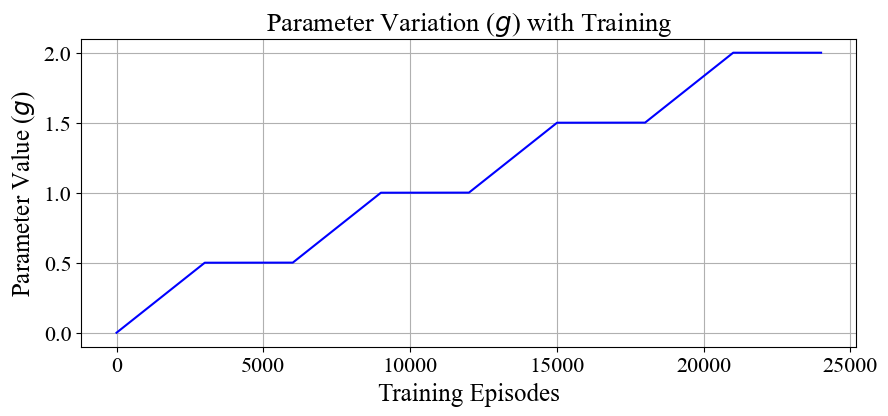

In [20]:
# Set parameters
# Define our training parameters
gravity_values = np.concatenate([
    np.linspace(0.0, 0.5, 3000),
    0.5*np.ones((3000, )),
    np.linspace(0.5, 1.0, 3000),
    1.0*np.ones((3000, )),
    np.linspace(1.0, 1.5, 3000),
    1.5*np.ones((3000, )),
    np.linspace(1.5, 2.0, 3000),
    2.0*np.ones((3000, ))
])

# Plot parameter variation
plt.figure(figsize=(10, 4))
plt.plot(gravity_values, color='blue')
plt.title(r'Parameter Variation ($g$) with Training')
plt.xlabel('Training Episodes')
plt.ylabel(r'Parameter Value ($g$)')
plt.grid(True)
plt.show()

# Train boolean
TRAIN = True  # Set to True to train, False to load saved results

# Test gravity values
test_gravity_values = np.linspace(0.0, 2.5, 26)  # 26 values from 0.0 to 2.5

Simulating the COIN model
Finding optimal context labels (trial = 50)
Finding optimal context labels (trial = 100)
Finding optimal context labels (trial = 150)
Finding optimal context labels (trial = 200)
Finding optimal context labels (trial = 250)
Finding optimal context labels (trial = 300)
Finding optimal context labels (trial = 350)
Finding optimal context labels (trial = 400)
Finding optimal context labels (trial = 450)
Permuting context labels (trial = 50)
Permuting context labels (trial = 100)
Permuting context labels (trial = 150)
Permuting context labels (trial = 200)
Permuting context labels (trial = 250)
Permuting context labels (trial = 300)
Permuting context labels (trial = 350)
Permuting context labels (trial = 400)
Permuting context labels (trial = 450)
Finding optimal context labels (trial = 50)
Finding optimal context labels (trial = 100)
Finding optimal context labels (trial = 150)
Finding optimal context labels (trial = 200)
Finding optimal context labels (trial = 2

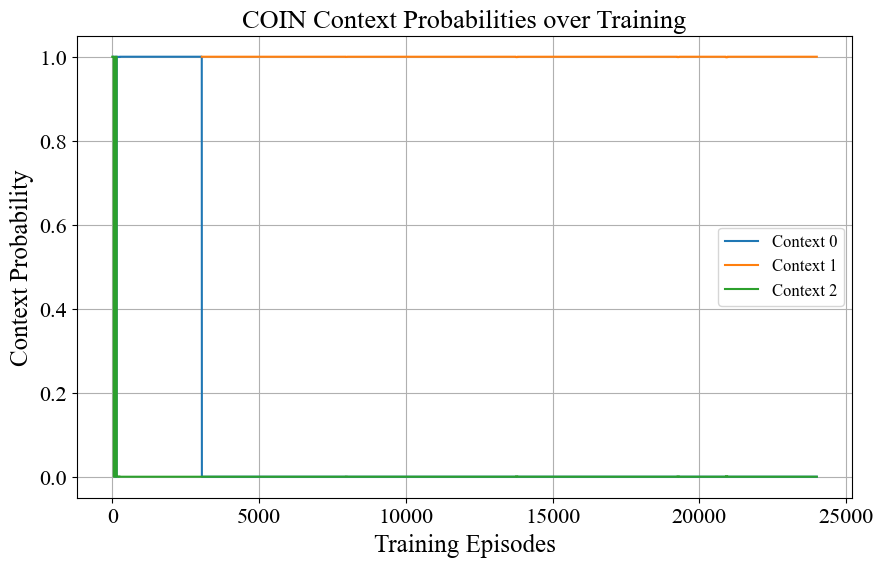

In [21]:
# Run COIN model
mean_retention = 0.9425 # Low retention mean to quickly lead to stationary distribution
precision_drift = 1/(1-mean_retention) # Precision for getting large stationary means (order 1) relative to our data
coin_model = COIN(
    sigma_sensory_noise = 0.003, 
    sigma_motor_noise = 0.00182,
    prior_precision_drift = precision_drift,
    prior_mean_retention = mean_retention, 
)

# Simplify COIN calculation by assuming parameters stay the same every 50 episodes
coin_model.perturbations = gravity_values[::50]

output = coin_model.simulate_coin()

known_c_resp, novel_c_resp = coin_model.get_responsibilities(output)
p_contexts_coin = np.concatenate([known_c_resp,novel_c_resp[:,None]],axis=-1) 

pred_resp = coin_model.get_predicted_responsibilities(output, test_gravity_values)

# Ensure interpolation of probabilities back to appropriate size
p_contexts_coin = np.repeat(p_contexts_coin, repeats=50, axis=0)
pred_resp = np.repeat(pred_resp, repeats=50, axis=1)

# Ensure COIN probabilities are of the right form
# Novel context - should never have a NaN definition
p_temp = p_contexts_coin.copy()
p_temp[np.isnan(p_temp)] = 0.0
p_contexts_coin[:,-1] = 1 - np.sum(p_temp[:,:-1], axis=1)
C = p_contexts_coin.shape[1]-1

# Obtain stationary probabilities, retention and drift per context
stat_probs = coin_model.get_stationary_probabilities(output)
stat_prob = stat_probs[0,-1,:] # Only last time input is relevant
retention_vals = np.linspace(0.8, 0.99, 500)
drift_vals = np.linspace(-2.00, 2.00, 500)
retention_prob, drift_prob = coin_model.get_retention_and_drift_given_context(output, retention_vals, drift_vals)

# Average mean and variance of state per context
# Find average mean and variances for each context for last trial (stationary)
s = coin_model.sigma_process_noise
context_details = {}
for c in range(C):
    p_retention = retention_prob[:, -1, c] / np.sum(retention_prob[:, -1, c])
    p_drift = drift_prob[:, -1, c] / np.sum(drift_prob[:, -1, c])

    # Find the average of drift distribution
    mean_drift = np.sum(drift_vals * p_drift)

    # Find the expectation of (1/1-retention)
    mean_a1 = np.nansum((1/(1-retention_vals)) * p_retention)

    # Find the expectation of (1/1-retention^2)
    mean_a2 = np.nansum((1/(1-retention_vals**2)) * p_retention)

    context_mean = mean_drift * mean_a1
    context_variance = s**2 * mean_a2
    context_details[c] = {
        'mean': context_mean,
        'variance': context_variance
    }
# Also add novel context with zero mean and high variance
context_details[C] = {
    'mean': 0.0,
    'variance': 10.0
}

# Print context details for checking
for c in range(C+1):
    print(f"Context {c}: Mean = {context_details[c]['mean']:.4f}, Variance = {context_details[c]['variance']:.4f}")

# Plot COIN context probabilities over training
plt.figure(figsize=(10, 6))
for c in range(p_contexts_coin.shape[1]):
    plt.plot(p_contexts_coin[:, c], label=f'Context {c}')
plt.title('COIN Context Probabilities over Training')
plt.xlabel('Training Episodes')
plt.ylabel('Context Probability')
plt.legend()
plt.grid(True)
plt.show()

## Mountain Car (COIN-Q)

In [ ]:
FIG10_COIN_Q_PATH = "models/fig10_coin_q_learning_agent.pkl"
if TRAIN:
    C = p_contexts_coin.shape[1]-1

    env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
    coin_agent = EmbodiedCOINQLearningAgent(
        env=env,
        max_contexts=C,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        alpha_body=1e-5,
        gamma=0.99,
        init_Q_random=False,
        exploration="softmax"
    )

    generalization_rewards = []
    training_rewards = []
    evaluation_rewards = []
    for t, g in tqdm(enumerate(gravity_values), total=len(gravity_values)):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=g, render_mode="none")
        
        # Train the agent in the current context
        training_reward = coin_agent.train_step(env=env, p_context=p_contexts_coin[t,:], max_steps_per_episode=200)
        training_rewards.append(training_reward)

        eval_r = coin_agent.evaluate(env, p_context=p_contexts_coin[t,:], n_episodes=1)[0]
        evaluation_rewards.append(eval_r)
          
        # Evaluate for all the test_gravity_values
        generalization_rewards_t = np.zeros((test_gravity_values.size,))

        if t==0 or t % 500 == 0:
            for i in range(generalization_rewards_t.size):
                eval_amp = test_gravity_values[i]
                env = CustomMountainCarEnv(gravity_sf=eval_amp, render_mode="none")

                generalization_rewards_t[i] = np.mean(coin_agent.evaluate(env, pred_resp[i,t,:], 10, 200, True)[0])
            generalization_rewards.append(generalization_rewards_t)

    # Stack into numpy arrays
    training_rewards = np.stack(training_rewards)
    evaluation_rewards = np.stack(evaluation_rewards)
    generalization_rewards = np.stack(generalization_rewards)
    
    # Save the trained agent and rewards together
    with open(FIG10_COIN_Q_PATH, "wb") as f:
        pickle.dump({
            'agent': coin_agent,
            'training_rewards': training_rewards,
            'evaluation_rewards': evaluation_rewards,
            'test_rewards': generalization_rewards
        }, f)
else:
    # Load the saved agent and rewards
    if os.path.exists(FIG10_COIN_Q_PATH):
        with open(FIG10_COIN_Q_PATH, "rb") as f:
            data = pickle.load(f)
            coin_agent = data['agent']
            training_rewards = data['training_rewards']
            evaluation_rewards = data['evaluation_rewards']
            generalization_rewards= data['test_rewards']
        print(f"Loaded COIN Q-learning agent and rewards from '{FIG10_COIN_Q_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved COIN Q-learning agent found at '{FIG10_COIN_Q_PATH}'.")

  0%|          | 0/24000 [00:00<?, ?it/s]

In [26]:
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 19,
    "axes.titlesize": 19,
    "axes.labelsize": 18,
    "legend.fontsize": 12,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16
})

# ── Normalize and mask zero entries ─────────────────────────────────────
data = generalization_rewards
data = (data - data.min()) / (data.max() - data.min())
masked_data = np.ma.masked_where(data == 0, data)
N, B = data.shape

# ── Create modified colormap with black for masked values ───────────────
cmap = plt.get_cmap('viridis').copy()
cmap.set_bad(color='black')

# ── Create figure and axes ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# ── Plot heatmap ────────────────────────────────────────────────────────
cax = ax.imshow(masked_data,
                origin='upper',
                aspect='auto',
                interpolation='nearest',
                vmin=0,
                vmax=1,
                cmap=cmap)

# ── Highlight training data ─────────────────────────────────────────────
d = gravity_values[::500]
col_indices = np.rint((d - test_gravity_values.min()) / (test_gravity_values.max() - test_gravity_values.min()) * (test_gravity_values.size - 1)).astype(int)
row_indices = np.arange(N)

ax.scatter(col_indices, row_indices,
           facecolors='red',
           edgecolors='white',
           s=50,
           linewidths=2,
           marker='o')

# ── Labels, ticks, colorbar ─────────────────────────────────────────
fig.colorbar(cax, ax=ax, label='Return (Scaled)')
ax.set_xlabel('Parameter Value')
ax.set_ylabel('Episode')

ax.set_xticks(np.arange(0, B, 2))
ax.set_yticks(np.arange(0, N, 5))
ax.set_xticklabels([f"{float(v):.2f}" for v in test_gravity_values[::2]])
ax.set_yticklabels(np.arange(0, len(gravity_values), 2500))

plt.tight_layout()
plt.show()


AttributeError: 'list' object has no attribute 'min'

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

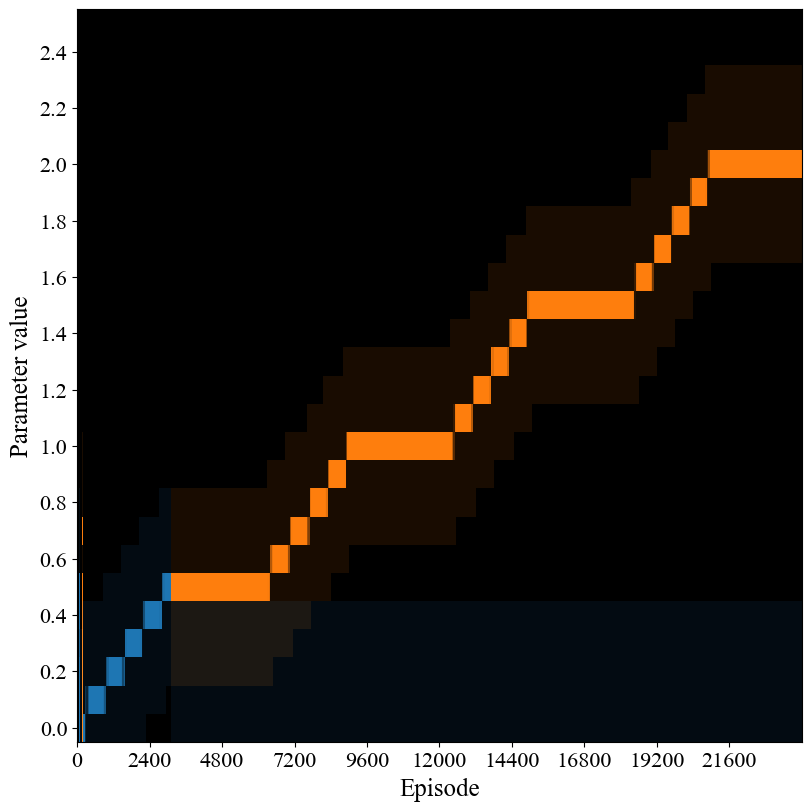

In [22]:
from utils.plot_utils import plot_context_probabilities, plot_hor_context_prob

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 19,
    "axes.titlesize": 19,
    "axes.labelsize": 18,
    "legend.fontsize": 12,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16
})

ax1 = plot_hor_context_prob(
    pred_resp,
    test_gravity_values,
    data,
    train_stride=50,
    min_intensity = 0.1,
    fig_size=(8,8)
)

# Set ax1 label
ax1.set_xlabel("Episode")
ax1.set_ylabel("Parameter Value")